<a href="https://colab.research.google.com/github/CharlieHubbard7/NFLResearch/blob/main/NFL_Research_(5_26_26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFL Research

This notebook contains my work for the second week of work with Professor Ron Yurko at Carnegie Mellon's Sports Analytics Center. I use Madden ratings to explore what stats teams value in players of different position groups

##Data Wrangling

In [14]:
!pip install nflreadpy #This is from the NFLverse package: https://github.com/nflverse/nflreadpy
!pip install rapidfuzz -q #This helps match the NFL roster with the madden data

In [15]:
import pandas as pd
import numpy as np
import string
import re
import math
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import nflreadpy as nfl
from rapidfuzz import fuzz, process
pd.set_option('display.max_columns', 250)
pd.set_option('display.min_rows', 10)

### NFL Verse Stats

In [16]:
pbp = nfl.load_pbp().to_pandas() # play-by-play data
player_stats = nfl.load_player_stats().to_pandas() # player game or season statistics
team_stats = nfl.load_team_stats().to_pandas() # team game or season statistics
# schedules = nfl.load_schedules().to_pandas() # game schedules and results
players = nfl.load_players().to_pandas() # player information
rosters = nfl.load_rosters().to_pandas() # team rosters
rosters_weekly = nfl.load_rosters_weekly().to_pandas() # team rosters by season-week
snap_counts = nfl.load_snap_counts().to_pandas() # snap counts
nextgen_stats = nfl.load_nextgen_stats().to_pandas() # advanced stats from nextgenstats.nfl.com
ftn_charting = nfl.load_ftn_charting().to_pandas() # charted stats from ftnfantasy.com/data
participation = nfl.load_participation().to_pandas() # participation data (historical)
draft_picks = nfl.load_draft_picks().to_pandas() # nfl draft picks
injuries = nfl.load_injuries().to_pandas() # injury statuses and practice participation
contracts = nfl.load_contracts().to_pandas() # historical contract data from OTC
officials = nfl.load_officials().to_pandas() # officials for each game
combine = nfl.load_combine().to_pandas() # nfl combine results
depth_charts = nfl.load_depth_charts().to_pandas() # depth charts
trades = nfl.load_trades().to_pandas() # trades
ff_playerids = nfl.load_ff_playerids().to_pandas() # ffverse/dynastyprocess player ids
ff_rankings = nfl.load_ff_rankings().to_pandas() # fantasypros rankings
ff_opportunity = nfl.load_ff_opportunity().to_pandas() # expected yards, touchdowns, and fantasy points

###Madden Stats

In [17]:
madden2026 = pd.read_csv("/content/drive/MyDrive/ipynb stuff/Madden_Ratings.csv")

FUZZY_SAME_TEAM_THRESHOLD = 83.4
FUZZY_ANY_TEAM_THRESHOLD  = 85

In [18]:
# Madden uses verbose position names; rosters uses abbreviations
position_mapping = {
    "Quarterback":    "QB", "Halfback":       "RB", "Fullback":     "FB",
    "Wide Receiver":  "WR", "Tight End":      "TE",
    "Left Tackle":    "OT", "Right Tackle":   "OT",
    "Left Guard":     "G",  "Right Guard":    "G",  "Center":       "C",
    "Left Edge":      "DE", "Right Edge":     "DE",
    "Defensive Tackle": "DT",
    "Mike Backer":    "MLB",
    "Sam Backer":     "OLB", "Weak Backer":   "OLB",
    "Cornerback":     "CB", "Free Safety":    "FS", "Strong Safety": "S",
    "Kicker":         "K",  "Punter":         "P",  "Long Snapper":  "LS",
}

# Madden uses full team names; rosters uses abbreviations.
# Note: Madden uses "NY Giants" / "NY Jets" — not the full city names.
team_mapping = {
    "Arizona Cardinals":    "ARI", "Atlanta Falcons":      "ATL",
    "Baltimore Ravens":     "BAL", "Buffalo Bills":        "BUF",
    "Carolina Panthers":    "CAR", "Chicago Bears":        "CHI",
    "Cincinnati Bengals":   "CIN", "Cleveland Browns":     "CLE",
    "Dallas Cowboys":       "DAL", "Denver Broncos":       "DEN",
    "Detroit Lions":        "DET", "Green Bay Packers":    "GB",
    "Houston Texans":       "HOU", "Indianapolis Colts":   "IND",
    "Jacksonville Jaguars": "JAX", "Kansas City Chiefs":   "KC",
    "Las Vegas Raiders":    "LV",  "Los Angeles Chargers": "LAC",
    "Los Angeles Rams":     "LA",  "Miami Dolphins":       "MIA",
    "Minnesota Vikings":    "MIN", "New England Patriots": "NE",
    "New Orleans Saints":   "NO",  "NY Giants":            "NYG",
    "NY Jets":              "NYJ", "Philadelphia Eagles":  "PHI",
    "Pittsburgh Steelers":  "PIT", "San Francisco 49ers":  "SF",
    "Seattle Seahawks":     "SEA", "Tampa Bay Buccaneers": "TB",
    "Tennessee Titans":     "TEN", "Washington Commanders":"WAS",
}

# Players whose fuzzy matches were manually reviewed and confirmed correct.
# These are nickname / encoding variants — e.g. Patrick → Pat, Da'Ron → Daron.
# Only matches in this set will receive a gsis_id from the fuzzy pass.
VERIFIED_FUZZY_MATCHES = {
    "Kenneth Murray",    "Zah Frazier",          "Tre' Harris",
    "Lajohntay Wester",  "Audric Estime",         "Joshua Palmer",
    "Chris Roland-Wallace", "Cor'Dale Flott",     "Matt Orzech",
    "Andres Borregales", "Da'Ron Payne",          "Drew Ogletree",
    "Foyesade Oluokun",  "Dru Phillips",          "Patrick Surtain",
    "Kamren Curl",       "Dax Hill",              "Olusegun Oluwatimi",
    "JuJu Brents",       "Benjamin Yurosek",      "Michael Jordan",
}

In [19]:
#Name normalization

def normalize_name(name: str) -> str:
    """
    Standardizes player names to reduce merge failures caused by formatting
    differences between Madden and nflverse roster data.

    Handles:
      - Suffixes     : Jr., Sr., II, III, IV, V  →  stripped
      - Initial dots : D.K. → DK,  A.J. → AJ
      - Apostrophes  : curly/backtick variants    →  straight apostrophe
      - Whitespace   : leading/trailing spaces    →  stripped
    """
    if pd.isna(name):
        return name
    name = str(name).strip()
    name = re.sub(r'[''`]', "'", name)                                               # normalize apostrophes
    name = re.sub(r'\s+(Jr\.?|Sr\.?|II|III|IV|V)$', '', name, flags=re.IGNORECASE)  # strip suffixes
    name = re.sub(r'(?<=[A-Z])\.(?=[A-Z]\.?|\s|$)', '', name)                       # strip initial periods
    return name.strip()


In [20]:
# Clean madden df

madden = madden2026.copy()

original_teams  = madden["Team"].copy()                          # preserve for error reporting
madden["Name"]  = (madden["First Name"] + " " + madden["Last Name"]).apply(normalize_name)
madden["position"] = madden["Position"].map(position_mapping)
madden["Team"]  = madden["Team"].map(team_mapping)
madden = madden.drop(columns=["First Name", "Last Name", "Position"])

# Reorder columns: identifiers first, then all Madden attributes
front_cols = ["Name", "position", "Team"]
madden     = madden[front_cols + [c for c in madden.columns if c not in front_cols]]

# Guard: any team that didn't map means team_mapping is incomplete
unmapped_teams = original_teams[madden["Team"].isna()].unique()
assert len(unmapped_teams) == 0, \
    f"[!] Unmapped teams — add to team_mapping: {unmapped_teams}"

madden["Name_norm"] = madden["Name"]   # name is already normalized; alias for merge key

#clean rosters df

rosters_clean = (
    rosters[["full_name", "gsis_id", "team"]]
    .copy()
    .assign(Name_norm=lambda df: df["full_name"].apply(normalize_name))
    .drop_duplicates(subset=["Name_norm", "team"])
)

print(f"Madden cleaned:  {len(madden):,} players")
print(f"Rosters cleaned: {len(rosters_clean):,} players")

Madden cleaned:  2,035 players
Rosters cleaned: 3,149 players


In [21]:

#Waterfall merge

# Merges from most to least specific, tracking residuals at every step.
#   Pass 1  —  Name + Team         (precise; handles same-name players on different teams)
#   Pass 2  —  Name only           (unambiguous only — one gsis_id per name in rosters)
#   Pass 3  —  Name only           (last resort — takes first match; flags for review)

def split_merge(df: pd.DataFrame):
    """
    Splits a post-merge dataframe into matched and unmatched rows.
    Strips roster join columns from unmatched rows to keep the schema clean.
    """
    matched   = df[df["gsis_id"].notna()].copy()
    unmatched = df[df["gsis_id"].isna()].drop(columns=["gsis_id", "full_name", "team"],
                                               errors="ignore")
    return matched, unmatched


# Pass 1: Name + Team
p1 = madden.merge(
    rosters_clean,
    left_on=["Name_norm", "Team"],
    right_on=["Name_norm", "team"],
    how="left"
)
matched_p1, unmatched_p1 = split_merge(p1)

# Pass 2: Name only — unambiguous matches
# Restrict to names where exactly one gsis_id exists across all rosters.
# Prevents incorrect matches when two players share the same normalized name.
name_uid_counts   = rosters_clean.groupby("Name_norm")["gsis_id"].nunique()
unambiguous_names = name_uid_counts[name_uid_counts == 1].index
rosters_unamb     = rosters_clean[rosters_clean["Name_norm"].isin(unambiguous_names)]

p2 = unmatched_p1.merge(
    rosters_unamb[["Name_norm", "gsis_id", "full_name", "team"]],
    on="Name_norm",
    how="left"
)
matched_p2, unmatched_p2 = split_merge(p2)

# Pass 3: Name only — last resort
# No ambiguity filter; accepts first match. Risky — fuzzy pass will catch errors.
p3 = unmatched_p2.merge(
    rosters_clean[["Name_norm", "gsis_id", "full_name", "team"]],
    on="Name_norm",
    how="left"
)
p3 = p3.drop_duplicates(subset=["Name"], keep="first")
matched_p3, still_missing = split_merge(p3)

print(f"[✓] Pass 1  (Name + Team):        {len(matched_p1):>4}  ({len(matched_p1)/len(madden):.1%})")
print(f"[✓] Pass 2  (Name, unambiguous):  {len(matched_p2):>4}")
print(f"[✓] Pass 3  (Name, last resort):  {len(matched_p3):>4}")
print(f"[→] Entering fuzzy match:         {len(still_missing):>4} remaining")

[✓] Pass 1  (Name + Team):        1567  (77.0%)
[✓] Pass 2  (Name, unambiguous):   403
[✓] Pass 3  (Name, last resort):     3
[→] Entering fuzzy match:           63 remaining


In [22]:
#Fuzzy Matching for Residuals

# Catches nickname variants (Patrick → Pat), encoding differences (accents,
# apostrophes), and minor spelling variations that exact merges cannot handle.
#
# Strategy:
#   1. Same-team match first  (lower threshold — team filter reduces false positives)
#   2. Any-team fallback       (higher threshold — no team context means more risk)

roster_name_list = rosters_clean["Name_norm"].tolist()

def fuzzy_match_player(
    madden_name: str,
    madden_team: str,
    rosters_df: pd.DataFrame,
    all_roster_names: list,
) -> tuple:
    """
    Finds the best fuzzy name match for a single unmatched player.

    Args:
        madden_name:      Normalized player name from Madden.
        madden_team:      Team abbreviation from Madden.
        rosters_df:       Cleaned rosters dataframe.
        all_roster_names: Precomputed list of all roster Name_norm values.

    Returns:
        Tuple of (matched_name, score, gsis_id). Returns (None, 0, None) if
        no match clears the threshold.
    """
    same_team = rosters_df[rosters_df["team"] == madden_team]

    # Attempt 1: same-team match
    if len(same_team) > 0:
        result = process.extractOne(
            madden_name, same_team["Name_norm"].tolist(), scorer=fuzz.token_sort_ratio
        )
        if result and result[1] >= FUZZY_SAME_TEAM_THRESHOLD:
            gsis = same_team[same_team["Name_norm"] == result[0]]["gsis_id"].values
            return result[0], result[1], (gsis[0] if len(gsis) > 0 else None)

    # Attempt 2: any-team match (compensate with higher threshold)
    result = process.extractOne(madden_name, all_roster_names, scorer=fuzz.token_sort_ratio)
    if result and result[1] >= FUZZY_ANY_TEAM_THRESHOLD:
        gsis = rosters_df[rosters_df["Name_norm"] == result[0]]["gsis_id"].values
        return result[0], result[1], (gsis[0] if len(gsis) > 0 else None)

    return None, 0, None


fuzzy_results = [
    {
        "Name":       row["Name"],
        "Team":       row["Team"],
        "Matched To": matched_to,
        "Score":      score,
        "gsis_id":    gsis_id,
    }
    for _, row in still_missing.iterrows()
    for matched_to, score, gsis_id in [
        fuzzy_match_player(row["Name"], row["Team"], rosters_clean, roster_name_list)
    ]
]

fuzzy_df = pd.DataFrame(fuzzy_results).sort_values("Score", ascending=False)
print(fuzzy_df.to_string())


                    Name Team                Matched To      Score     gsis_id
47        Kenneth Murray  DAL           Kenneth Murray,  96.551724  00-0036441
39           Zah Frazier  CHI              Zach Frazier  95.652174  00-0039896
29           Tre' Harris  LAC                Tre Harris  95.238095  00-0040727
36      Lajohntay Wester  BAL          LaJohntay Wester  93.750000  00-0040075
34         Audric Estime   NO             Audric Estimé  92.307692  00-0039373
18         Joshua Palmer  BUF               Josh Palmer  91.666667  00-0036988
42  Chris Roland-Wallace   KC  Christian Roland-Wallace  90.909091  00-0039324
10        Cor'Dale Flott  NYG             Cordale Flott  88.888889  00-0037758
58           Matt Orzech   GB            Matthew Orzech  88.000000  00-0035118
25     Andres Borregales   NE           Andy Borregales  87.500000  00-0040200
4           Da'Ron Payne  WAS               Daron Payne  86.956522  00-0034333
17      Darious Williams   LA            Mario Willi

In [23]:

# Apply Verified Fuzzy Matches

# Fuzzy matching can produce false positives (e.g. "Logan Wilson" matching
# "Roman Wilson"). Only matches in VERIFIED_FUZZY_MATCHES — confirmed correct
# via manual review — are accepted. All others remain in the dataset with
# gsis_id = NaN. A Madden rating is still analytically valid without a
# roster match.

verified_gsis = (
    fuzzy_df[
        fuzzy_df["Name"].isin(VERIFIED_FUZZY_MATCHES) &
        fuzzy_df["gsis_id"].notna()
    ]
    [["Name", "gsis_id"]]
)

# Merge verified gsis_ids back into all still-missing rows
matched_fuzzy = still_missing.merge(verified_gsis, on="Name", how="left")

accepted  = matched_fuzzy["gsis_id"].notna().sum()
remaining = matched_fuzzy["gsis_id"].isna().sum()
print(f"[✓] Fuzzy matches accepted:  {accepted}")
print(f"[→] No gsis_id (kept):       {remaining}  — Madden rating still valid")


[✓] Fuzzy matches accepted:  18
[→] No gsis_id (kept):       45  — Madden rating still valid


In [24]:
# Final Assembly & Validation

# Combine all passes. Sort by Overall descending before deduplication so that
# when a player appears twice in Madden (e.g. traded mid-year), the higher-rated
# entry is kept.
all_matched = pd.concat([matched_p1, matched_p2, matched_p3, matched_fuzzy],
                        ignore_index=True)
all_matched = all_matched.drop(columns=["Name_norm", "full_name", "team"], errors="ignore")
all_matched = all_matched.sort_values("Overall", ascending=False)

# Deduplicate on gsis_id — but only where gsis_id is not null.
# Deduplicating on NaN would incorrectly collapse all unmatched players into one row.
has_gsis    = all_matched[all_matched["gsis_id"].notna()].drop_duplicates(subset=["gsis_id"], keep="first")
no_gsis     = all_matched[all_matched["gsis_id"].isna()]
madden_final = pd.concat([has_gsis, no_gsis], ignore_index=True) \
                 .sort_values("Overall", ascending=False)          \
                 .reset_index(drop=True)

# ── Validation Report ─────────────────────────────────────────────────────────
total        = len(madden_final)
with_gsis    = madden_final["gsis_id"].notna().sum()
without_gsis = madden_final["gsis_id"].isna().sum()

print("═" * 52)
print("  FINAL DATASET SUMMARY")
print("═" * 52)
print(f"  Total players:             {total:>5,}")
print(f"  Matched to roster:         {with_gsis:>5,}  ({with_gsis/total:.1%})")
print(f"  No gsis_id (valid):        {without_gsis:>5,}  ({without_gsis/total:.1%})")
print("═" * 52)
print(f"  Breakdown by pass:")
print(f"    Pass 1  (Name + Team):         {len(matched_p1):>4}")
print(f"    Pass 2  (Name, unambiguous):   {len(matched_p2):>4}")
print(f"    Pass 3  (Name, last resort):   {len(matched_p3):>4}")
print(f"    Fuzzy   (verified):            {accepted:>4}")
print(f"    No match (null gsis_id):       {without_gsis:>4}")
print("═" * 52)

════════════════════════════════════════════════════
  FINAL DATASET SUMMARY
════════════════════════════════════════════════════
  Total players:             2,032
  Matched to roster:         1,987  (97.8%)
  No gsis_id (valid):           45  (2.2%)
════════════════════════════════════════════════════
  Breakdown by pass:
    Pass 1  (Name + Team):         1567
    Pass 2  (Name, unambiguous):    403
    Pass 3  (Name, last resort):      3
    Fuzzy   (verified):              18
    No match (null gsis_id):         45
════════════════════════════════════════════════════


In [25]:
madden = madden_final.copy()
madden.head(10)

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE,gsis_id
0,Ja'Marr Chase,WR,CIN,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5oemvWKqCFgB...,94,92,98,96,73,99,98,37,29,88,71,94,98,97,98,10,27,46,92,90,17,24,60,27,13,97,99,37,20,26,10,17,10,15,36,99,53,27,31,Default,96,97,95,83,76,39,10,15,20,19,33,22,88,71,17,00-0036900
1,Josh Allen,QB,BUF,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/212FXcpkDUjs...,91,85,92,98,81,97,97,23,98,86,63,20,40,82,13,9,11,26,99,81,14,22,13,17,12,15,99,14,10,15,97,15,9,9,33,18,17,10,10,Default Stride Bread Loaf,22,23,88,78,83,32,90,88,97,99,98,94,98,76,18,00-0034857
2,Lane Johnson,OT,PHI,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1Nt5pFCpjcBc...,78,75,82,88,93,99,60,56,39,30,67,58,64,58,25,60,60,95,84,54,22,25,10,96,12,33,99,98,94,98,39,29,53,10,55,45,97,96,98,Default,46,57,77,50,55,60,50,54,59,52,65,41,91,65,20,00-0030561
3,Myles Garrett,DE,CLE,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4qbblHggBjaH...,90,86,94,89,96,97,39,96,12,34,55,21,52,71,4,93,84,90,92,36,20,20,10,17,51,8,99,45,45,45,10,94,99,44,97,31,45,45,45,Long Stride Default,15,25,87,40,48,92,27,30,31,23,55,16,87,36,51,00-0033868
4,Christian Gonzalez,CB,NE,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/6Z0rWjQfkWgv...,93,94,95,90,59,98,75,53,10,67,60,62,74,95,20,37,49,48,90,74,42,46,55,15,98,27,98,30,24,25,6,98,28,86,77,40,32,27,32,Default Stride Loose,37,73,96,66,57,76,6,10,15,10,35,10,78,42,90,00-0039147
5,Micah Parsons,DE,GB,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4ztQk5Xogdkr...,95,90,85,90,91,97,71,80,12,57,69,44,62,77,31,97,84,84,93,71,20,20,60,20,59,36,98,45,45,45,6,95,92,57,94,36,45,45,45,Default Stride Loose,40,47,90,61,58,89,6,6,6,6,30,15,87,62,64,00-0036932
6,George Kittle,TE,SF,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1SoIzWJtk28y...,87,83,90,94,82,99,92,31,18,78,75,89,95,77,77,18,38,78,88,82,22,19,31,65,15,79,98,62,58,62,10,35,20,20,36,83,77,71,76,Default Stride Loose,84,89,87,64,83,34,10,15,20,10,30,14,98,84,24,00-0033288
7,Matthew Stafford,QB,LA,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/wS8JnLBEBj9e...,70,71,75,91,66,99,71,26,73,52,62,15,26,66,12,10,12,27,87,55,25,28,10,17,10,14,98,25,22,24,90,17,10,10,29,15,22,19,17,Default,15,15,78,39,36,28,95,95,98,88,95,84,98,47,22,00-0026498
8,Jahmyr Gibbs,RB,DET,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/7cuE4tZcli1u...,95,93,81,85,72,88,92,30,25,84,96,64,74,92,63,10,28,32,90,96,10,14,80,29,12,69,98,51,29,34,10,16,10,16,37,65,30,24,16,Default,73,64,98,94,72,30,13,17,21,15,26,14,84,82,15,00-0039139
9,Penei Sewell,OT,DET,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/7cuE4tZcli1u...,74,60,70,95,97,98,20,35,13,15,35,17,44,58,5,16,33,96,94,10,20,23,10,97,12,17,98,90,86,94,6,19,24,10,37,15,99,99,99,Default Stride Awkward,28,15,73,10,25,32,6,6,6,6,18,14,91,30,12,00-0036880


### Historical Madden Data

Credit to: https://github.com/theedgepredictor/nfl-madden-data/tree/main/data/madden/dataset for the data collection

In [26]:
madden_long = pd.read_parquet("/content/drive/MyDrive/ipynb stuff/madden_hist.parquet")
madden_long.head()

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year
0,00-0004543,SHANEDRONETT_d_line,DronSh20,Shane Dronett,def,d_line,DL,2001,ATL,1.0,75.0,53.0,65.0,58.0,79.0,84.0,84.0,79.0,81.0,43.0,7.347195,4,11,35.306958,66.518996,11.0,20.0,20.0,20.0,16.696763,19.318944,28.0,-2.261149,-1.546120,2.340851,3.478826,22.0,6.519022,10.549796,11.996476,9.005981,8.412261,8.034401,16.0,16.0,0.483380,15.249485,17.082539,81.0,51.752871,8.673651,66.456748,21.0,24.0,0.675884,2001
1,00-0012842,JASONPETER_d_line,PeteJa20,Jason Peter,def,d_line,DL,2001,CAR,1.0,74.0,66.0,74.0,64.0,84.0,78.0,84.0,80.0,67.0,51.0,7.889415,5,7,47.836493,58.864012,10.0,21.0,21.0,21.0,18.295792,21.480056,24.0,0.980120,-0.375920,8.238861,7.495244,21.0,5.982346,9.869347,12.073328,5.724684,4.637821,9.797546,27.0,18.0,9.782409,19.028072,23.221269,72.0,54.472249,12.652961,69.286862,18.0,19.0,3.772098,2001
2,00-0009978,LEONARDLITTLE_d_line,LittLe00,Leonard Little,def,d_line,DL,2001,LAR,1.0,73.0,72.0,62.0,75.0,65.0,70.0,70.0,82.0,64.0,52.0,25.090824,8,9,51.656422,55.302556,32.0,14.0,14.0,14.0,11.934877,13.800475,24.0,19.994085,18.021897,24.959818,21.045019,40.0,8.751804,11.499611,12.645619,17.544412,14.431167,17.109987,16.0,24.0,-5.096101,32.979157,37.209780,74.0,51.286358,28.416331,72.007990,11.0,33.0,1.131921,2001
3,00-0002142,JUNIORBRYANT_d_line,BryaJu20,Junior Bryant,def,d_line,DL,2001,SF,1.0,72.0,49.0,62.0,55.0,81.0,81.0,84.0,84.0,79.0,43.0,5.111116,5,9,36.576845,65.727568,24.0,11.0,11.0,11.0,9.494538,11.093699,14.0,-8.819708,-2.912042,-5.407254,-5.493794,14.0,7.008726,10.117281,12.240143,-1.108932,-1.319240,1.354661,29.0,27.0,7.181824,14.503342,17.728221,82.0,51.302609,6.509206,64.948565,12.0,14.0,1.162361,2001
4,00-0018054,REINARDWILSON_d_line,WilsRe20,Reinard Wilson,def,d_line,DL,2001,CIN,1.0,69.0,70.0,70.0,65.0,78.0,69.0,78.0,77.0,65.0,50.0,16.121217,7,9,50.852213,56.274011,31.0,16.0,16.0,16.0,16.041897,17.385281,26.0,12.748664,9.218156,18.243457,14.183115,26.0,7.190139,10.575620,11.980324,12.149089,9.289694,10.978948,13.0,9.0,-2.869764,26.808503,31.008670,69.0,51.400124,22.833778,69.883798,17.0,21.0,2.545349,2001


## Analysis

### Observing what Madden stats are the best predictors of big contracts

**Justification for using apy_cap_pct as the metric that describes player's contracts vale:** To compare player contracts across years and positions, we use APY as a percentage of the NFL salary cap (apy_cap_pct) rather than raw dollar figures. The salary cap has grown significantly over time. For example, it has grown from roughly 120 million in 2012 to over 255 million in 2024, which means a $15M per year deal carries a fundamentally different cost to a team depending on when it was signed. By expressing each contract as a share of the cap in the year it was signed, we normalize for this growth and put all contracts on the same scale. This also allows for fair cross-positional comparisons: a quarterback and a cornerback operating in different salary markets are both evaluated by how much of a team's total resources they consume, rather than by raw dollar figures that reflect positional norms more than individual value.

In [ ]:
contracts_short = contracts.query("is_active == True")[["gsis_id", "year_signed", "apy_cap_pct", "inflated_apy", "draft_overall", "draft_year" ]]
contracts_short = contracts_short.sort_values("year_signed", ascending=False) \
                                  .drop_duplicates(subset="gsis_id", keep="first")
contracts_short.head()

,gsis_id,year_signed,apy_cap_pct,inflated_apy,draft_overall,draft_year
51554,00-0034067,2026,0.000,0.0000,NaN,2017.0
51293,00-0033196,2026,0.004,1.2150,NaN,2016.0
51281,00-0037412,2026,0.004,1.2400,NaN,2022.0
51238,00-0038769,2026,0.005,1.4525,NaN,2023.0
51233,00-0027224,2026,0.005,1.4875,NaN,2010.0


In [ ]:
madden_with_contracts = madden.merge(contracts_short, on="gsis_id", how="left")
madden_with_contracts.head()

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE,gsis_id,year_signed,apy_cap_pct,inflated_apy,draft_overall,draft_year
0,Ja'Marr Chase,WR,CIN,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5oemvWKqCFgB...,94,92,98,96,73,99,98,37,29,88,71,94,98,97,98,10,27,46,92,90,17,24,60,27,13,97,99,37,20,26,10,17,10,15,36,99,53,27,31,Default,96,97,95,83,76,39,10,15,20,19,33,22,88,71,17,00-0036900,2025.0,0.144,43.421562,5.0,2021.0
1,Josh Allen,QB,BUF,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/212FXcpkDUjs...,91,85,92,98,81,97,97,23,98,86,63,20,40,82,13,9,11,26,99,81,14,22,13,17,12,15,99,14,10,15,97,15,9,9,33,18,17,10,10,Default Stride Bread Loaf,22,23,88,78,83,32,90,88,97,99,98,94,98,76,18,00-0034857,2025.0,0.197,59.333811,7.0,2018.0
2,Lane Johnson,OT,PHI,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1Nt5pFCpjcBc...,78,75,82,88,93,99,60,56,39,30,67,58,64,58,25,60,60,95,84,54,22,25,10,96,12,33,99,98,94,98,39,29,53,10,55,45,97,96,98,Default,46,57,77,50,55,60,50,54,59,52,65,41,91,65,20,00-0030561,2025.0,0.090,26.969914,4.0,2013.0
3,Myles Garrett,DE,CLE,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4qbblHggBjaH...,90,86,94,89,96,97,39,96,12,34,55,21,52,71,4,93,84,90,92,36,20,20,10,17,51,8,99,45,45,45,10,94,99,44,97,31,45,45,45,Long Stride Default,15,25,87,40,48,92,27,30,31,23,55,16,87,36,51,00-0033868,2025.0,0.143,43.151862,1.0,2017.0
4,Christian Gonzalez,CB,NE,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/6Z0rWjQfkWgv...,93,94,95,90,59,98,75,53,10,67,60,62,74,95,20,37,49,48,90,74,42,46,55,15,98,27,98,30,24,25,6,98,28,86,77,40,32,27,32,Default Stride Loose,37,73,96,66,57,76,6,10,15,10,35,10,78,42,90,00-0039147,2023.0,0.017,5.058923,17.0,2023.0


In [ ]:
list(madden_with_contracts["position"].unique())

['WR',
 'QB',
 'OT',
 'DE',
 'CB',
 'RB',
 'TE',
 'MLB',
 'G',
 'DT',
 'C',
 'FS',
 'S',
 'OLB',
 'K',
 'FB',
 'P',
 'LS']

In [ ]:
def plotPositionAndFeature(data, position, feature):
  position = position.upper()
  feature = feature.upper()
  df = data.dropna(subset = "gsis_id").query("position == @position")[["Name", feature, "apy_cap_pct", "Overall", "Player Image", "gsis_id"]]
  plt.scatter(df[feature], df["apy_cap_pct"])
  plt.xlabel(f"{feature} (Madden Rating)")
  plt.ylabel("Average Salary Per Year as a Percentage of the Salary Cap")
  plt.title(f"Average Yearly Salary as Cap Percentage across Madden speed ratings for {position}s")
  plt.show()

#### WR Analysis

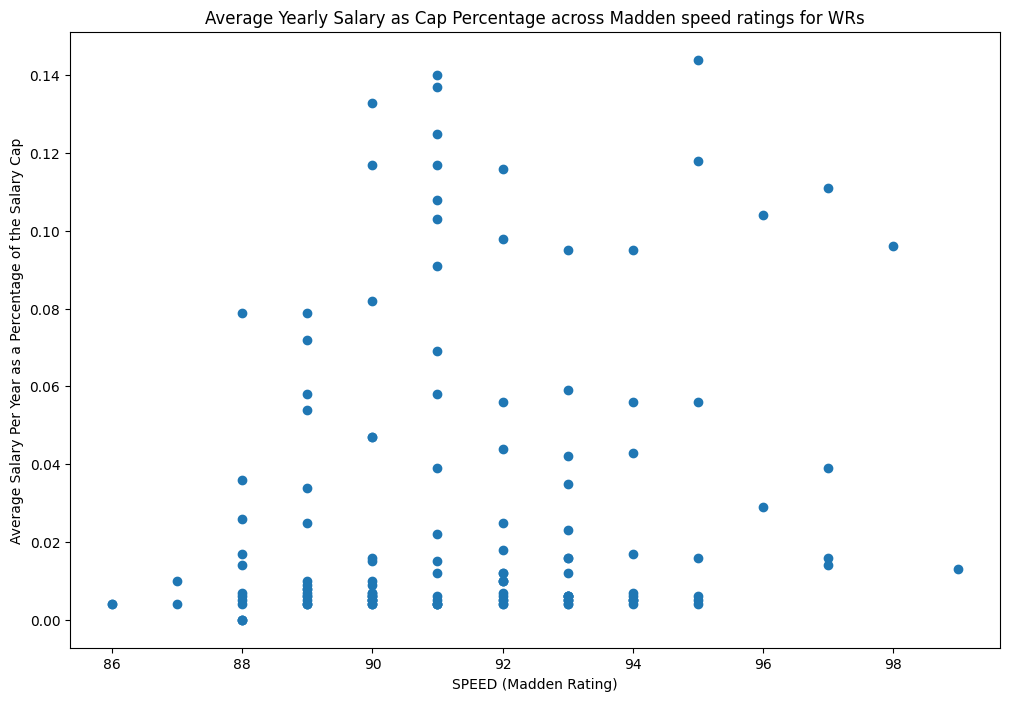

In [ ]:
plt.figure(figsize=(12, 8))
plotPositionAndFeature(madden_with_contracts.query("Overall > 70"), "WR", "SPEED")

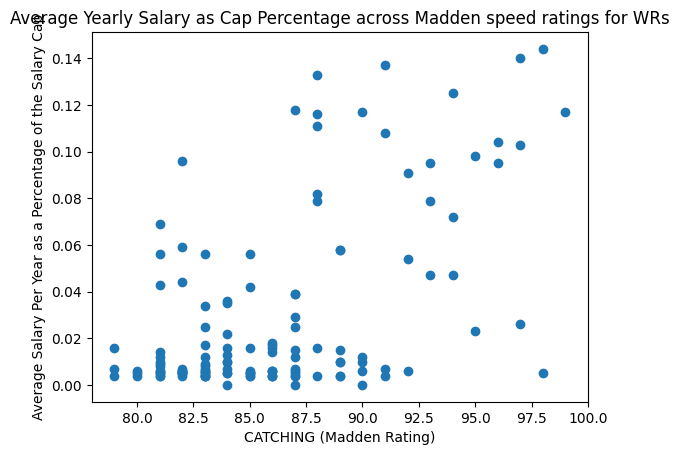

In [ ]:
plotPositionAndFeature(madden_with_contracts.query("Overall > 70"), "WR", "CATCHING")

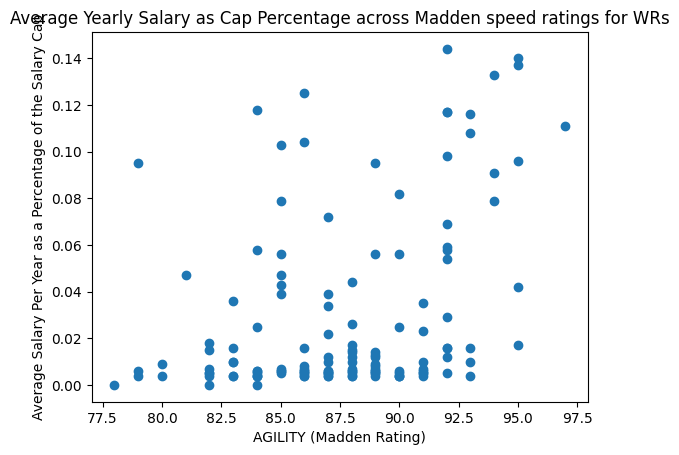

In [ ]:
plotPositionAndFeature(madden_with_contracts.query("Overall > 70"), "WR", "AGILITY")

In [ ]:
features = [feature for feature in madden_with_contracts.columns[6:-6] if feature not in ["OVERALL", "RUNNINGSTYLE"]]

wr = (madden_with_contracts
      .query("position == 'WR' and draft_year <= 2021")
      .dropna(subset=["apy_cap_pct"])
      .copy())

# print(features)
corr_with_salary = (
    wr[features + ["apy_cap_pct"]]
    .corr()["apy_cap_pct"]
    .drop("apy_cap_pct")
    .sort_values(key=abs, ascending=False)
)

print(corr_with_salary)

MEDIUMROUTERUNNING    0.856941
SHORTROUTERUNNING     0.843250
DEEPROUTERUNNING      0.833650
RELEASE               0.813492
SPECTACULARCATCH      0.801503
BCVISION              0.777357
STAMINA               0.757744
CATCHINTRAFFIC        0.753937
BREAKTACKLE           0.752918
AWARENESS             0.734126
CATCHING              0.712318
JUMPING               0.690360
JUKEMOVE              0.687319
SPINMOVE              0.632346
CHANGEOFDIRECTION     0.599616
AGILITY               0.574334
STIFFARM              0.547539
TRUCKING              0.543449
TOUGHNESS             0.537665
SPEED                 0.446067
INJURY                0.440689
ACCELERATION          0.413579
STRENGTH              0.310413
KICKPOWER             0.245358
RUNBLOCKFINESSE       0.166974
CARRYING              0.155578
PLAYRECOGNITION      -0.136839
RUNBLOCK              0.120667
RUNBLOCKPOWER         0.104463
IMPACTBLOCKING        0.094450
PLAYACTION           -0.093325
BLOCKSHEDDING         0.091323
PASSBLOC

In [ ]:
corr_with_salary.reset_index().rename(columns={"index": "Feature", "apy_cap_pct": "Correlation"})

corr_with_salary = pd.DataFrame(corr_with_salary).reset_index()
corr_with_salary

,index,apy_cap_pct
0,MEDIUMROUTERUNNING,0.856941
1,SHORTROUTERUNNING,0.843250
2,DEEPROUTERUNNING,0.833650
3,RELEASE,0.813492
4,SPECTACULARCATCH,0.801503
5,BCVISION,0.777357
6,STAMINA,0.757744
7,CATCHINTRAFFIC,0.753937
8,BREAKTACKLE,0.752918
9,AWARENESS,0.734126


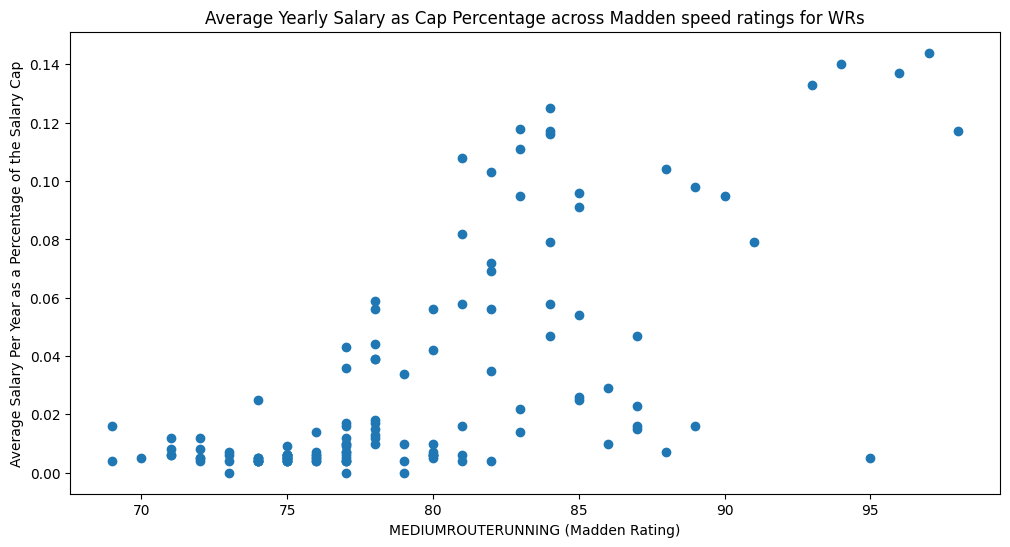

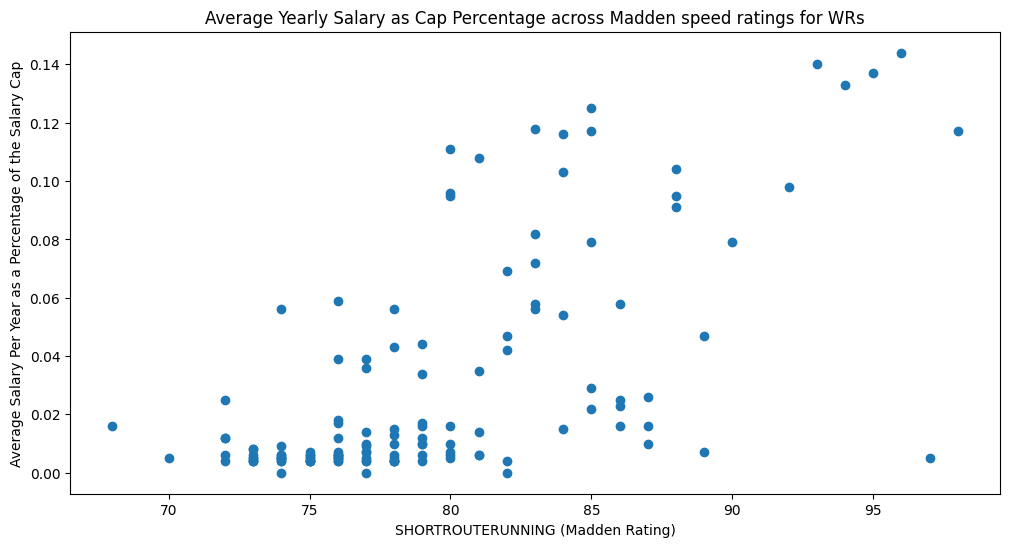

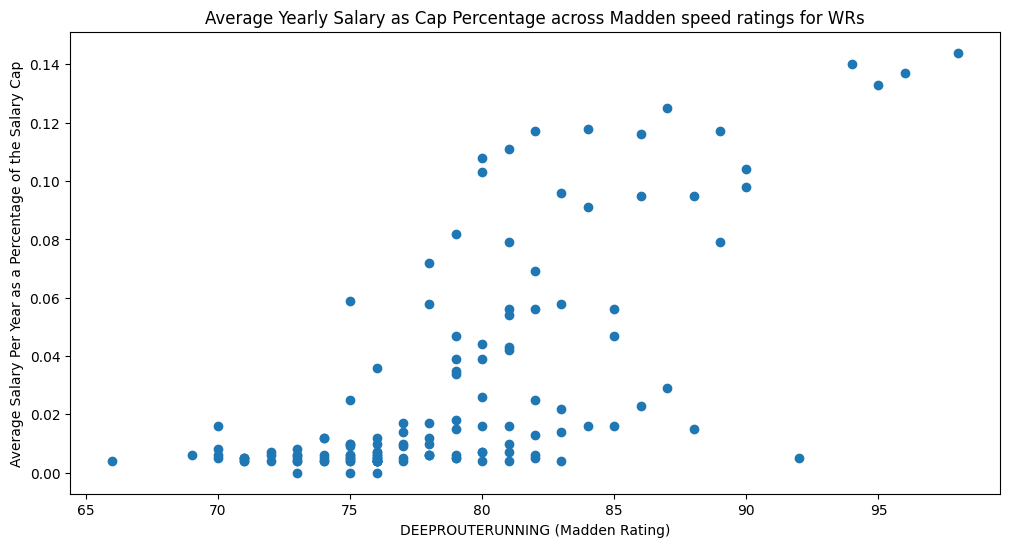

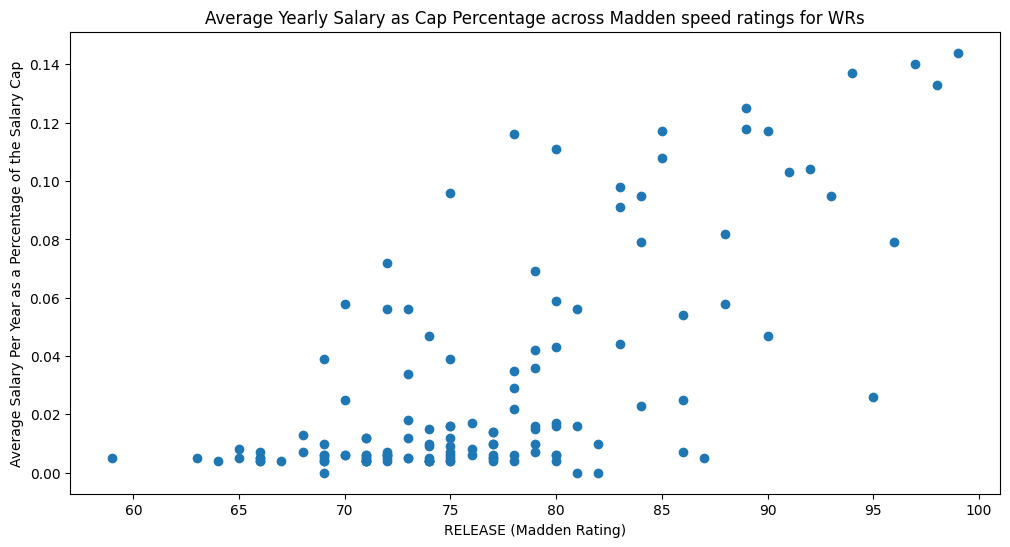

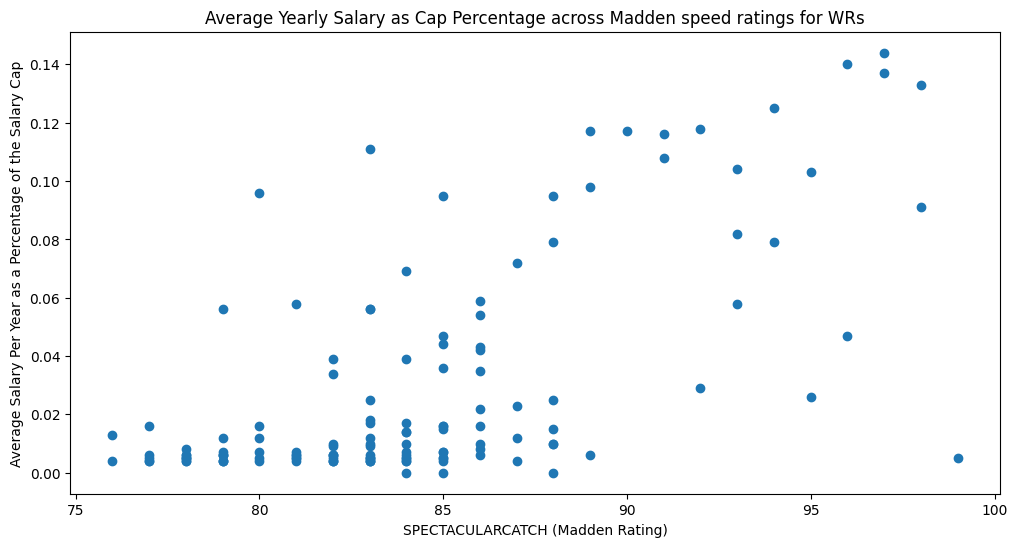

In [ ]:
for feature in corr_with_salary["index"].head(5):
    plt.figure(figsize=(12, 6))
    plotPositionAndFeature(madden_with_contracts.query("Overall > 70"), "WR", feature)

##### Random forest to find the most important features:

WRs: 59  |  Features: 53


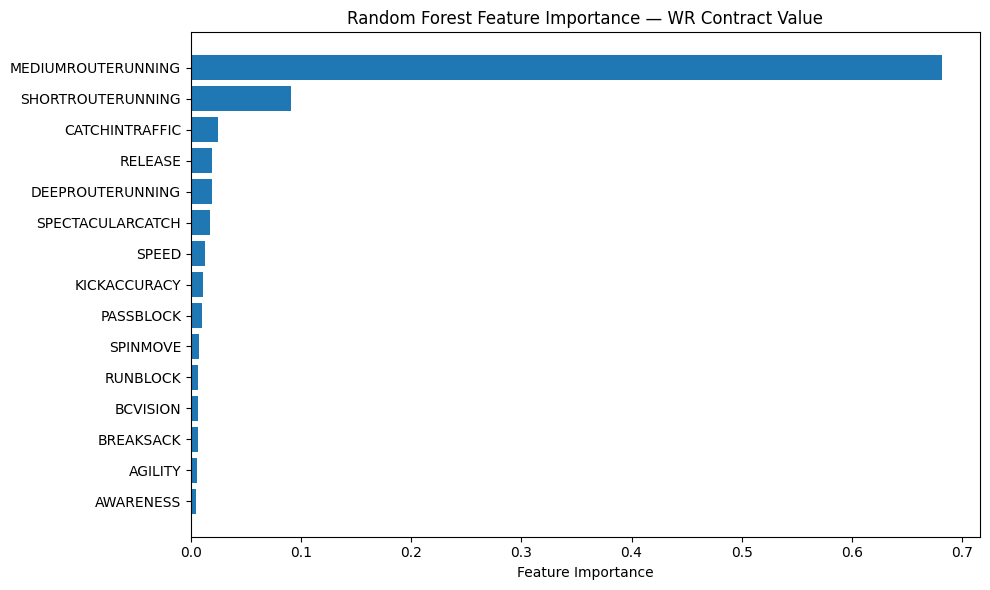


LASSO surviving features:
               Feature  Coefficient
0   MEDIUMROUTERUNNING     0.015623
1              JUMPING     0.008541
2            LEADBLOCK     0.007652
3              AGILITY     0.006825
4             CATCHING     0.005924
5           THROWPOWER     0.005283
6            BREAKSACK     0.004339
7            TOUGHNESS     0.003845
8     DEEPROUTERUNNING     0.003667
9             STRENGTH     0.003049
10        ZONECOVERAGE     0.002959
11           KICKPOWER     0.002840
12        KICKACCURACY     0.002832
13         BREAKTACKLE     0.002403
14            TRUCKING     0.002275
15          POWERMOVES     0.002264
16               SPEED     0.001371
17    SPECTACULARCATCH     0.001363
18          KICKRETURN     0.001289
19            JUKEMOVE     0.000869
20   CHANGEOFDIRECTION     0.000584
21            CARRYING     0.000278
22            STIFFARM     0.000167
23            HITPOWER     0.000103


In [ ]:
wr = (madden_with_contracts
      .query("position == 'WR' and draft_year <= 2021")
      .dropna(subset=["apy_cap_pct"])
      .copy())

# Madden attribute columns — drop non-numeric / identifier columns
exclude = ["Name", "position", "Team", "Overall", "Player Image", "gsis_id",
           "apy_cap_pct", "player", "team", "value", "apy", "guaranteed",
           "inflated_value", "inflated_apy", "inflated_guaranteed",
           "player_page", "otc_id", "date_of_birth", "college",
           "draft_year", "draft_round", "draft_overall", "draft_team",
           "year_signed", "years", "height", "weight", "is_active", "Overall", "OVERALL"]

features = [c for c in wr.columns if c not in exclude and wr[c].dtype in ["int64", "float64"]]
X = wr[features].fillna(wr[features].median())
y = wr["apy_cap_pct"]

print(f"WRs: {len(wr)}  |  Features: {len(features)}")

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X, y)

importance_df = (pd.DataFrame({"Feature": features, "Importance": rf.feature_importances_})
                   .sort_values("Importance", ascending=False)
                   .reset_index(drop=True))

# Plot top 15
top15 = importance_df.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top15["Feature"][::-1], top15["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance — WR Contract Value")
plt.tight_layout()
plt.show()

# ── LASSO sanity check ────────────────────────────────────────────────────────
scaler      = StandardScaler()
X_scaled    = scaler.fit_transform(X)
lasso       = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

lasso_df = (pd.DataFrame({"Feature": features, "Coefficient": np.abs(lasso.coef_)})
              .sort_values("Coefficient", ascending=False)
              .query("Coefficient > 0")
              .reset_index(drop=True))

print("\nLASSO surviving features:")
print(lasso_df.to_string())

/tmp/ipykernel_1520/4088945849.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


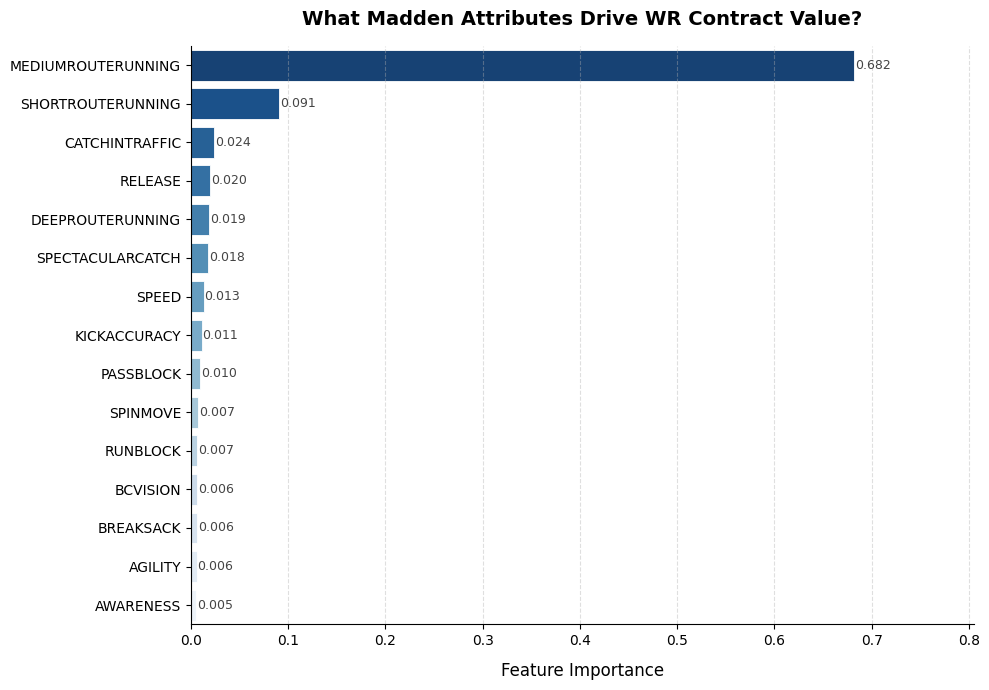

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=top15.sort_values("Importance", ascending=False),
    x="Importance",
    y="Feature",
    palette="Blues_r",  # darker = more important
    edgecolor="white",
    linewidth=0.6,
    ax=ax
)

# Add value labels on each bar
for bar, (_, row) in zip(ax.patches, top15.sort_values("Importance", ascending=False).iterrows()):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Importance']:.3f}",
        va="center", ha="left",
        fontsize=9, color="#444444"
    )

ax.set_xlabel("Feature Importance", fontsize=12, labelpad=10)
ax.set_ylabel("")
ax.set_title("What Madden Attributes Drive WR Contract Value?",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, top15["Importance"].max() * 1.18)  # room for labels
sns.despine(left=False, bottom=False)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

#### QB Analysis

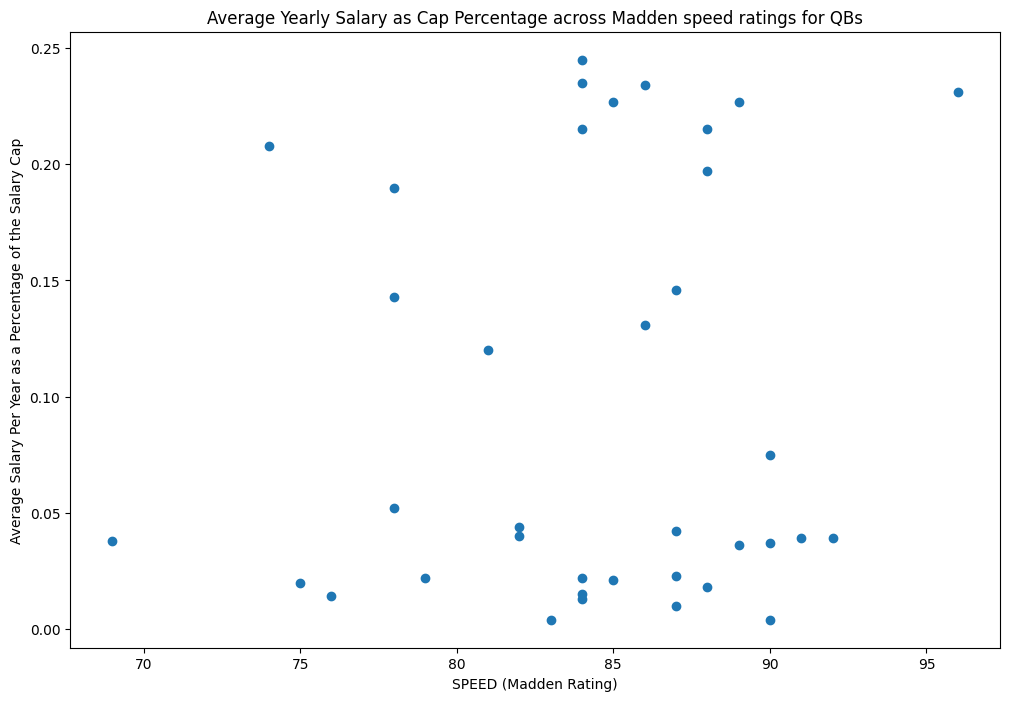

In [ ]:
plt.figure(figsize=(12, 8))
plotPositionAndFeature(madden_with_contracts.query("Overall > 70"), "QB", "SPEED")

In [ ]:
features = [feature for feature in madden_with_contracts.columns[6:-6] if feature not in ["OVERALL", "RUNNINGSTYLE"]]

qb = (madden_with_contracts
      .query("position == 'QB' and draft_year <= 2021")
      .dropna(subset=["apy_cap_pct"])
      .copy())

# print(features)
corr_with_salary = (
    qb[features + ["apy_cap_pct"]]
    .corr()["apy_cap_pct"]
    .drop("apy_cap_pct")
    .sort_values(key=abs, ascending=False)
)

print(corr_with_salary)

THROWONTHERUN         0.783898
THROWUNDERPRESSURE    0.766539
THROWACCURACYMID      0.746458
THROWACCURACYSHORT    0.740974
AWARENESS             0.734286
STAMINA               0.718828
PLAYACTION            0.700661
THROWACCURACYDEEP     0.657815
BREAKSACK             0.581986
THROWPOWER            0.573787
STRENGTH              0.532713
TRUCKING              0.522197
STIFFARM              0.487957
BCVISION              0.486420
TOUGHNESS             0.476490
BREAKTACKLE           0.432489
JUKEMOVE              0.405150
SPEED                 0.397536
ACCELERATION          0.385819
PURSUIT               0.342263
AGILITY               0.325937
HITPOWER              0.324054
INJURY                0.323404
JUMPING               0.304636
CHANGEOFDIRECTION     0.274081
CARRYING              0.257324
TACKLE                0.254104
SPINMOVE              0.204543
RUNBLOCK              0.173692
FINESSEMOVES         -0.166120
IMPACTBLOCKING        0.160221
BLOCKSHEDDING         0.158370
CATCHINT

###Exploring Next Gen Stats and Madden Rating

#### WR Try 1

In [ ]:
madden

,Name,position,Team,Overall,Player Image,Team Logo,ACCELERATION,AGILITY,JUMPING,STAMINA,STRENGTH,AWARENESS,BCVISION,BLOCKSHEDDING,BREAKSACK,BREAKTACKLE,CARRYING,CATCHINTRAFFIC,CATCHING,CHANGEOFDIRECTION,DEEPROUTERUNNING,FINESSEMOVES,HITPOWER,IMPACTBLOCKING,INJURY,JUKEMOVE,KICKACCURACY,KICKPOWER,KICKRETURN,LEADBLOCK,MANCOVERAGE,MEDIUMROUTERUNNING,OVERALL,PASSBLOCK,PASSBLOCKFINESSE,PASSBLOCKPOWER,PLAYACTION,PLAYRECOGNITION,POWERMOVES,PRESS,PURSUIT,RELEASE,RUNBLOCK,RUNBLOCKFINESSE,RUNBLOCKPOWER,RUNNINGSTYLE,SHORTROUTERUNNING,SPECTACULARCATCH,SPEED,SPINMOVE,STIFFARM,TACKLE,THROWACCURACYDEEP,THROWACCURACYMID,THROWACCURACYSHORT,THROWONTHERUN,THROWPOWER,THROWUNDERPRESSURE,TOUGHNESS,TRUCKING,ZONECOVERAGE,gsis_id
0,Ja'Marr Chase,WR,CIN,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/5oemvWKqCFgB...,94,92,98,96,73,99,98,37,29,88,71,94,98,97,98,10,27,46,92,90,17,24,60,27,13,97,99,37,20,26,10,17,10,15,36,99,53,27,31,Default,96,97,95,83,76,39,10,15,20,19,33,22,88,71,17,00-0036900
1,Josh Allen,QB,BUF,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/212FXcpkDUjs...,91,85,92,98,81,97,97,23,98,86,63,20,40,82,13,9,11,26,99,81,14,22,13,17,12,15,99,14,10,15,97,15,9,9,33,18,17,10,10,Default Stride Bread Loaf,22,23,88,78,83,32,90,88,97,99,98,94,98,76,18,00-0034857
2,Lane Johnson,OT,PHI,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/1Nt5pFCpjcBc...,78,75,82,88,93,99,60,56,39,30,67,58,64,58,25,60,60,95,84,54,22,25,10,96,12,33,99,98,94,98,39,29,53,10,55,45,97,96,98,Default,46,57,77,50,55,60,50,54,59,52,65,41,91,65,20,00-0030561
3,Myles Garrett,DE,CLE,99,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/4qbblHggBjaH...,90,86,94,89,96,97,39,96,12,34,55,21,52,71,4,93,84,90,92,36,20,20,10,17,51,8,99,45,45,45,10,94,99,44,97,31,45,45,45,Long Stride Default,15,25,87,40,48,92,27,30,31,23,55,16,87,36,51,00-0033868
4,Christian Gonzalez,CB,NE,98,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/6Z0rWjQfkWgv...,93,94,95,90,59,98,75,53,10,67,60,62,74,95,20,37,49,48,90,74,42,46,55,15,98,27,98,30,24,25,6,98,28,86,77,40,32,27,32,Default Stride Loose,37,73,96,66,57,76,6,10,15,10,35,10,78,42,90,00-0039147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027,Chris Oladokun,QB,KC,55,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/3g9AewmTPjE4...,84,80,79,76,60,45,68,23,65,52,61,21,41,76,13,10,18,28,90,58,23,23,22,21,9,16,55,12,12,16,73,15,10,9,32,17,21,23,18,Default,19,21,82,55,35,28,69,70,75,76,85,72,87,37,10,00-0037324
2028,Feleipe Franks,TE,ATL,54,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/3NTxf2X9VWdF...,84,78,79,78,65,62,73,22,65,59,70,71,76,78,45,9,24,52,87,66,53,61,40,52,12,48,54,49,49,47,79,15,9,10,28,52,50,51,46,Default,53,67,84,63,50,26,74,71,78,72,90,70,88,49,18,00-0036825
2029,Brandon Allen,QB,TEN,54,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/2YxvlDMaJsJw...,70,76,70,65,56,61,52,21,56,30,59,20,26,74,15,9,11,21,85,47,20,21,13,11,12,17,54,17,18,14,75,21,9,9,28,19,16,10,10,Default,18,20,75,28,31,24,70,69,78,72,82,72,75,29,18,00-0032434
2030,Matt Nelson,OT,MIN,54,https://ratings-images-prod.pulse.ea.com/madde...,https://drop-assets.ea.com/images/bzuWJaOZo5LC...,63,64,75,84,75,68,10,59,12,5,35,28,43,57,20,55,70,76,89,10,11,21,10,77,12,24,54,60,58,61,6,58,58,10,63,31,63,60,64,Long Stride Awkward,27,34,67,10,10,68,6,6,6,6,16,13,87,21,12,00-0035328


In [ ]:
ngsR = nfl.load_nextgen_stats(2025, 'receiving').to_pandas()

In [ ]:
ngsR.query("week == 0")

,season,season_type,week,player_display_name,player_position,team_abbr,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,receptions,targets,catch_percentage,yards,rec_touchdowns,avg_yac,avg_expected_yac,avg_yac_above_expectation,player_gsis_id,player_first_name,player_last_name,player_jersey_number,player_short_name
0,2025,REG,0,Marvin Mims,WR,DEN,7.816410,4.528700,8.966863,10.444707,37,51,72.549020,322.0,1,6.515135,6.042606,0.472529,00-0038976,Marvin,Mims,19,M.Mims
1,2025,REG,0,Tre Tucker,WR,LV,7.618736,3.621922,10.305435,29.081841,57,92,61.956522,696.0,5,5.249825,5.017805,0.232020,00-0038563,Tre,Tucker,1,T.Tucker
2,2025,REG,0,Luther Burden,WR,CHI,7.425192,4.630455,7.264833,9.733446,47,60,78.333333,652.0,2,7.417872,6.491091,0.926782,00-0040735,Luther,Burden,10,L.Burden
3,2025,REG,0,Jordan Addison,WR,MIN,7.279870,2.867291,14.401519,29.910562,42,79,53.164557,610.0,3,3.589286,2.962784,0.626502,00-0038994,Jordan,Addison,3,J.Addison
4,2025,REG,0,Josh Downs,WR,IND,7.213919,2.680503,7.738295,15.883275,58,88,65.909091,559.0,4,2.677241,2.542907,0.134334,00-0038997,Joshua,Downs,2,J.Downs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2025,REG,0,Nico Collins,WR,HOU,4.872137,2.313167,12.904250,34.094107,71,120,59.166667,1117.0,6,4.875915,3.187746,1.688169,00-0036554,Nico,Collins,12,N.Collins
116,2025,REG,0,Jake Tonges,TE,SF,4.869211,3.587329,5.251522,5.921472,34,46,73.913043,293.0,5,4.734706,4.902458,-0.167752,00-0037112,Jake,Tonges,88,J.Tonges
117,2025,REG,0,Mark Andrews,TE,BAL,4.649524,2.910679,7.816714,16.233464,48,70,68.571429,422.0,5,2.278958,2.687631,-0.408672,00-0034753,Mark,Andrews,89,M.Andrews
118,2025,REG,0,AJ Barner,TE,SEA,4.621852,4.103580,4.763235,8.580610,52,68,76.470588,519.0,6,5.357500,4.576088,0.781412,00-0039793,A.J.,Barner,88,A.Barner


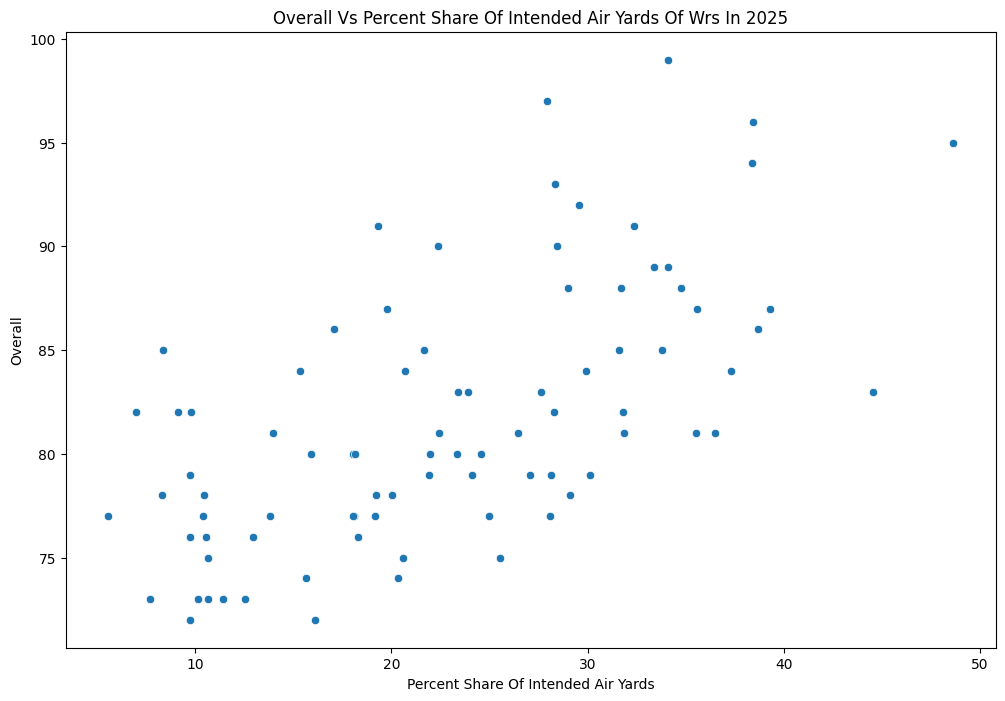

In [ ]:
temp = ngsR.sort_values("avg_yac_above_expectation", ascending = False).dropna(subset = "avg_yac_above_expectation").query("week == 0 and targets >= 20 and player_position == 'WR'")
tempMadden = madden[["gsis_id", "Overall"]]
temp2 = temp.merge(tempMadden, left_on="player_gsis_id", right_on="gsis_id")

def plotFunc(x, y, data, title):
  plt.figure(figsize=(12, 8))
  sns.scatterplot(data=data, x = x, y = y)
  plt.xlabel(x.replace("_", ' ').title())
  plt.ylabel(y)
  plt.title(title.replace("_", " ").title())
  plt.show()

plotFunc("percent_share_of_intended_air_yards", "Overall", temp2, "Overall vs percent_share_of_intended_air_yards of WRs in 2025")

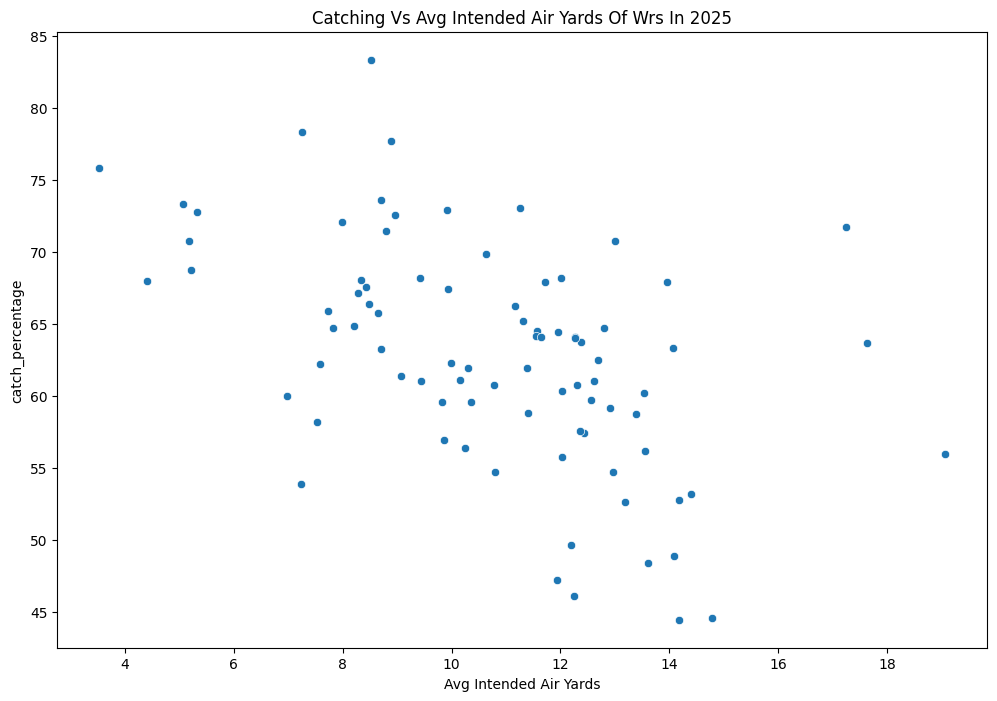

In [ ]:
temp = ngsR.sort_values("avg_yac_above_expectation", ascending = False).dropna(subset = "avg_yac_above_expectation").query("week == 0 and targets >= 20 and player_position == 'WR'")
tempMadden = madden[["gsis_id", "Overall", "CATCHING"]]
temp2 = temp.merge(tempMadden, left_on="player_gsis_id", right_on="gsis_id")

plotFunc("avg_intended_air_yards", "catch_percentage", temp2, "CATCHING vs avg_intended_air_yards of WRs in 2025")

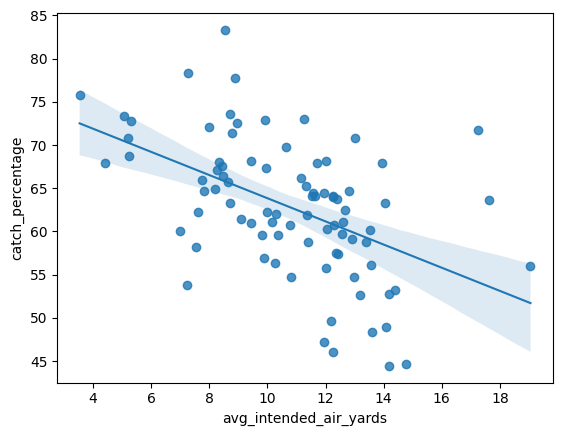

In [ ]:
sns.regplot(data=temp2, x="avg_intended_air_yards", y="catch_percentage", order = 1, scatter=True,
            line_kws={"linewidth": 1.5})
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = temp2[["avg_intended_air_yards"]]
y = temp2["catch_percentage"]

model = LinearRegression().fit(X, y)
temp2["expected_catch_pct"] = model.predict(X)
temp2["catch_above_expected"] = temp2["catch_percentage"] - temp2["expected_catch_pct"]

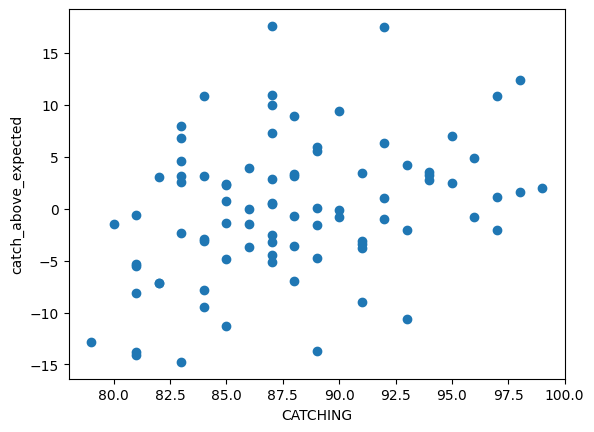

In [ ]:
plt.scatter(temp2["CATCHING"], temp2["catch_above_expected"])
plt.xlabel("CATCHING")
plt.ylabel("catch_above_expected")
plt.show()

#### WR Try 2

In [ ]:
wr_ngs = nfl.load_nextgen_stats(2025, "receiving").to_pandas()
wr_ngs = wr_ngs.merge(madden[["gsis_id", "Overall"]], left_on="player_gsis_id", right_on="gsis_id")
wr_ngs["yards_per_target"] = wr_ngs["yards"] / wr_ngs["targets"]
wr_ngs.head(1)

,season,season_type,week,player_display_name,player_position,team_abbr,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,receptions,targets,catch_percentage,yards,rec_touchdowns,avg_yac,avg_expected_yac,avg_yac_above_expectation,player_gsis_id,player_first_name,player_last_name,player_jersey_number,player_short_name,gsis_id,Overall,yards_per_target
0,2025,REG,0,Marvin Mims,WR,DEN,7.81641,4.5287,8.966863,10.444707,37,51,72.54902,322.0,1,6.515135,6.042606,0.472529,00-0038976,Marvin,Mims,19,M.Mims,00-0038976,78,6.313725


In [ ]:
wr_ngs_cleaned = wr_ngs.query("player_position == 'WR' and receptions >= 20")
wr_ngs_cleaned.head(1)

,season,season_type,week,player_display_name,player_position,team_abbr,avg_cushion,avg_separation,avg_intended_air_yards,percent_share_of_intended_air_yards,receptions,targets,catch_percentage,yards,rec_touchdowns,avg_yac,avg_expected_yac,avg_yac_above_expectation,player_gsis_id,player_first_name,player_last_name,player_jersey_number,player_short_name,gsis_id,Overall,yards_per_target
0,2025,REG,0,Marvin Mims,WR,DEN,7.81641,4.5287,8.966863,10.444707,37,51,72.54902,322.0,1,6.515135,6.042606,0.472529,00-0038976,Marvin,Mims,19,M.Mims,00-0038976,78,6.313725


In [ ]:
exclude = {
    'season', 'season_type', 'week', 'player_display_name', 'player_position',
    'team_abbr', 'player_gsis_id', 'player_first_name', 'player_last_name',
    'player_jersey_number', 'player_short_name', 'gsis_id', 'Overall'
}

features = [col for col in wr_ngs_cleaned.columns if col not in exclude]
features

['avg_cushion',
 'avg_separation',
 'avg_intended_air_yards',
 'percent_share_of_intended_air_yards',
 'receptions',
 'targets',
 'catch_percentage',
 'yards',
 'rec_touchdowns',
 'avg_yac',
 'avg_expected_yac',
 'avg_yac_above_expectation',
 'yards_per_target']

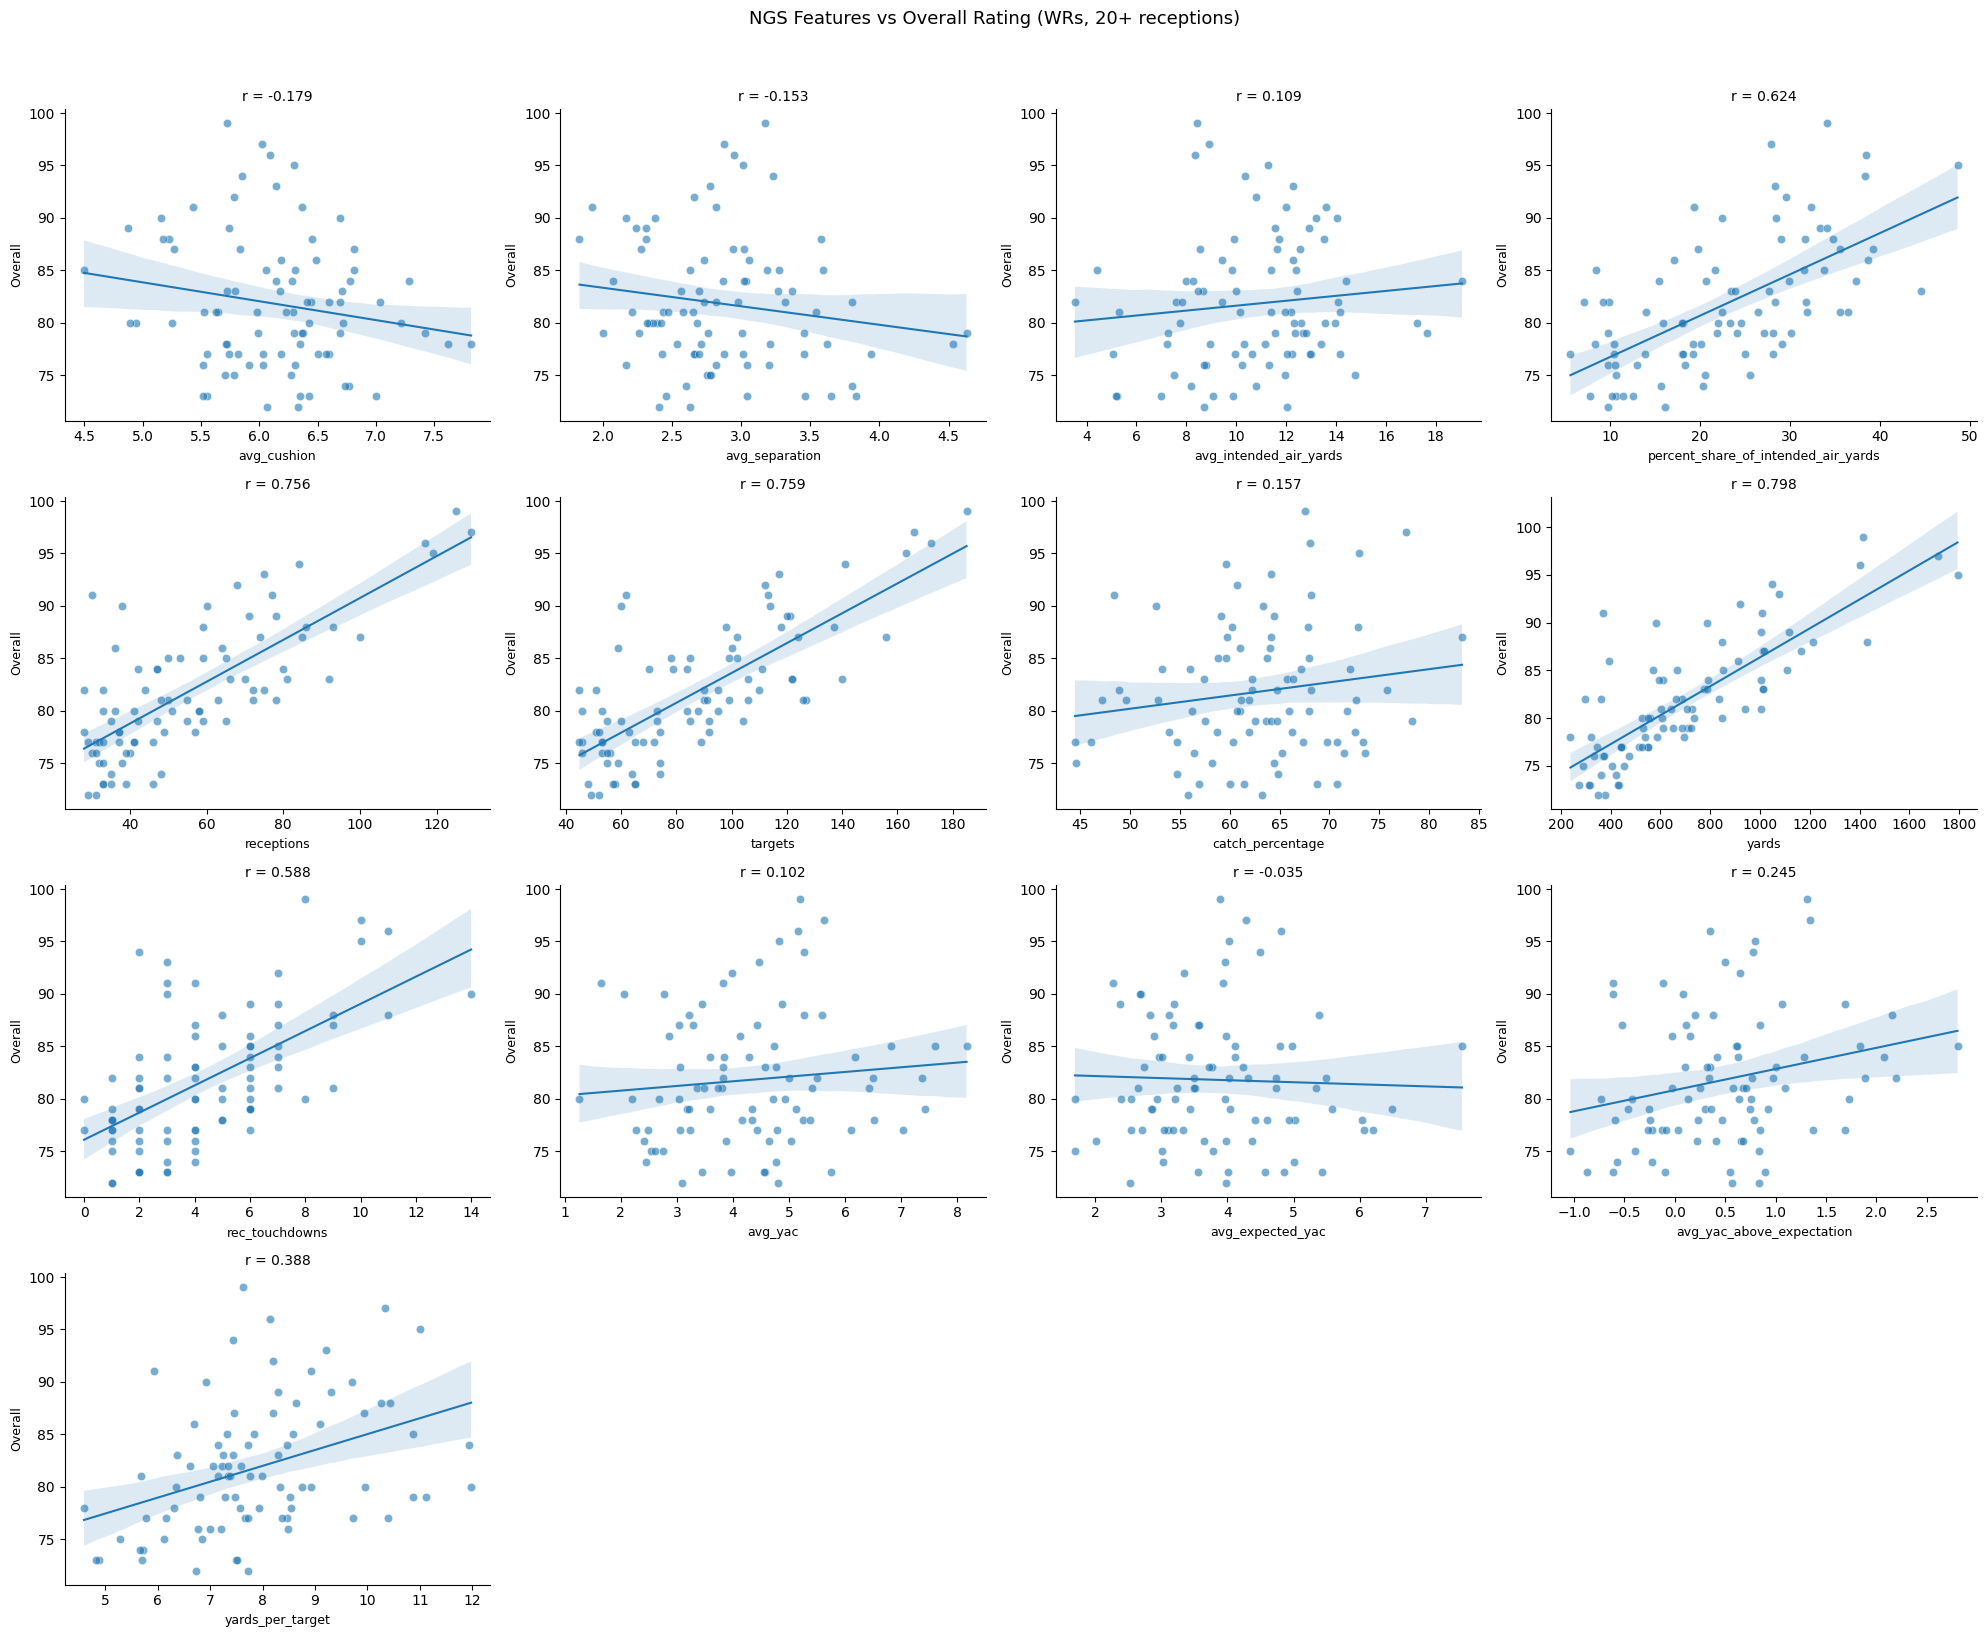

In [ ]:
n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    correlation = wr_ngs_cleaned[feature].corr(wr_ngs_cleaned["Overall"])

    sns.scatterplot(data=wr_ngs_cleaned, x=feature, y="Overall", alpha=0.6, ax=ax)
    sns.regplot(data=wr_ngs_cleaned, x=feature, y="Overall", scatter=False,
                line_kws={"linewidth": 1.5}, ax=ax)

    ax.set_title(f"r = {round(correlation, 3)}", fontsize=10)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel("Overall", fontsize=9)

# hide any empty subplots if features don't fill the grid perfectly
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

sns.despine()
plt.suptitle("NGS Features vs Overall Rating (WRs, 20+ receptions)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Observing Changes in Madden Ratings Across Years Per Position Group

In [18]:
sns.set_palette('rocket')

In [19]:
# first year each player appeared
madden_long["rookie_year"] = madden_long.groupby("player_id")["year"].transform("min")

# years in NFL relative to rookie year (1-indexed)
madden_long["years_in_nfl"] = madden_long["year"] - madden_long["rookie_year"] + 1

# baseline overall = their rating in year 1
baseline = (madden_long[madden_long["years_in_nfl"] == 1]
            .set_index("player_id")["overallrating"])

madden_long["baseline_overall"] = madden_long["player_id"].map(baseline)

# delta vs baseline
madden_long["overall_vs_baseline"] = madden_long["overallrating"] - madden_long["baseline_overall"]

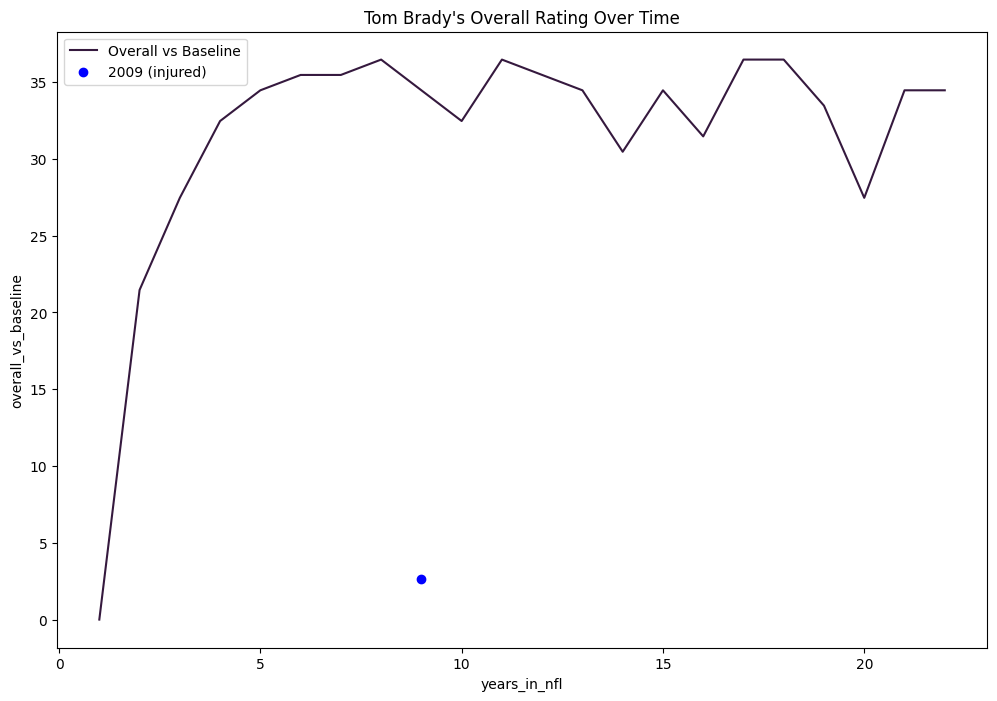

In [20]:
temp = madden_long.query("fullname == 'Tom Brady' and season != 2009")
outlier = madden_long.query("fullname == 'Tom Brady' and season == 2009")
plt.figure(figsize=(12, 8))

ax = sns.lineplot(data=temp, x="years_in_nfl", y="overall_vs_baseline", label="Overall vs Baseline")
ax.scatter(outlier["years_in_nfl"], outlier["overall_vs_baseline"],
           color="blue", zorder=5, label="2009 (injured)")

ax.legend()
plt.title("Tom Brady's Overall Rating Over Time")
plt.show()

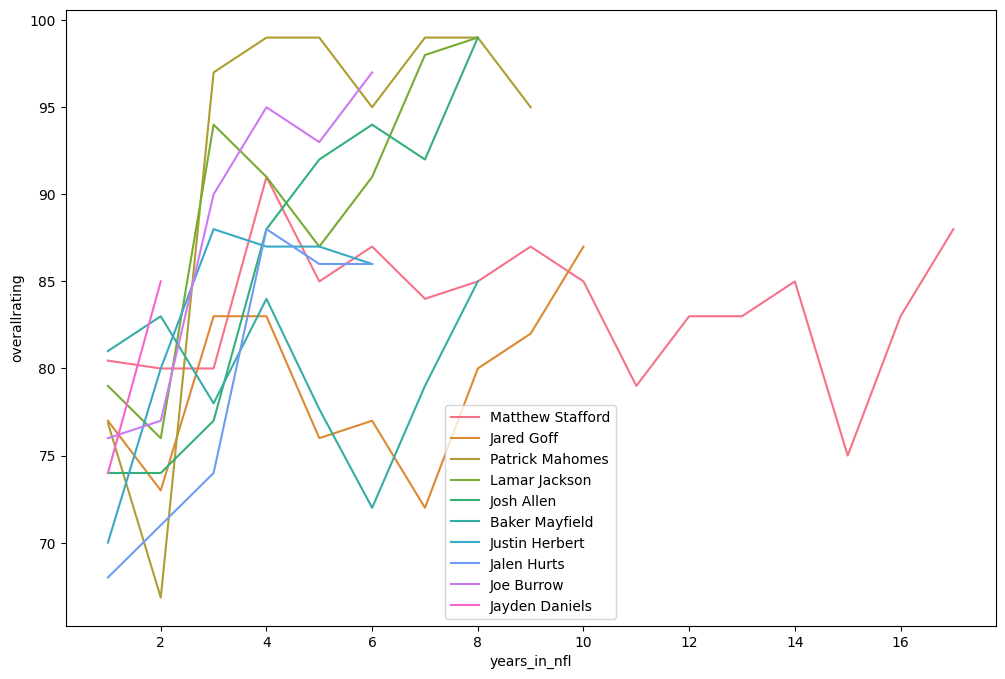

In [21]:
top10_ids = (madden_long
    .query("season == 2025 and position == 'QB'")
    .sort_values('overallrating', ascending=False)
    .head(10)
    ["player_id"]
    .tolist()
)

temp = madden_long.query("player_id in @top10_ids")
plt.figure(figsize=(12, 8))
ax = sns.lineplot(data=temp, x="years_in_nfl", y="overallrating", hue="fullname")
ax.legend()
plt.show()


In [22]:
temp = madden_long.groupby(["position_group", "years_in_nfl"])['overallrating'].mean().reset_index()
temp

,position_group,years_in_nfl,overallrating
0,d_field,1.0,66.392000
1,d_field,2.0,69.025983
2,d_field,3.0,72.136065
3,d_field,4.0,74.136365
4,d_field,5.0,75.781613
...,...,...,...
163,special_teams,15.0,78.878349
164,special_teams,16.0,79.024187
165,special_teams,17.0,80.244361
166,special_teams,18.0,78.292031


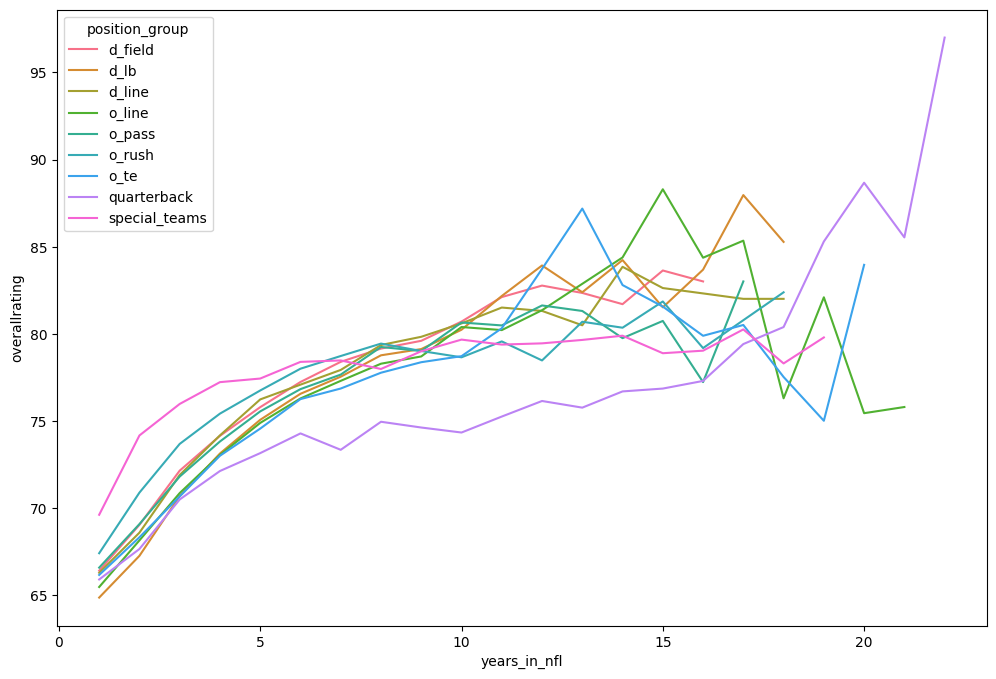

In [23]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=temp, x = "years_in_nfl", y = "overallrating", hue = "position_group")
plt.show()

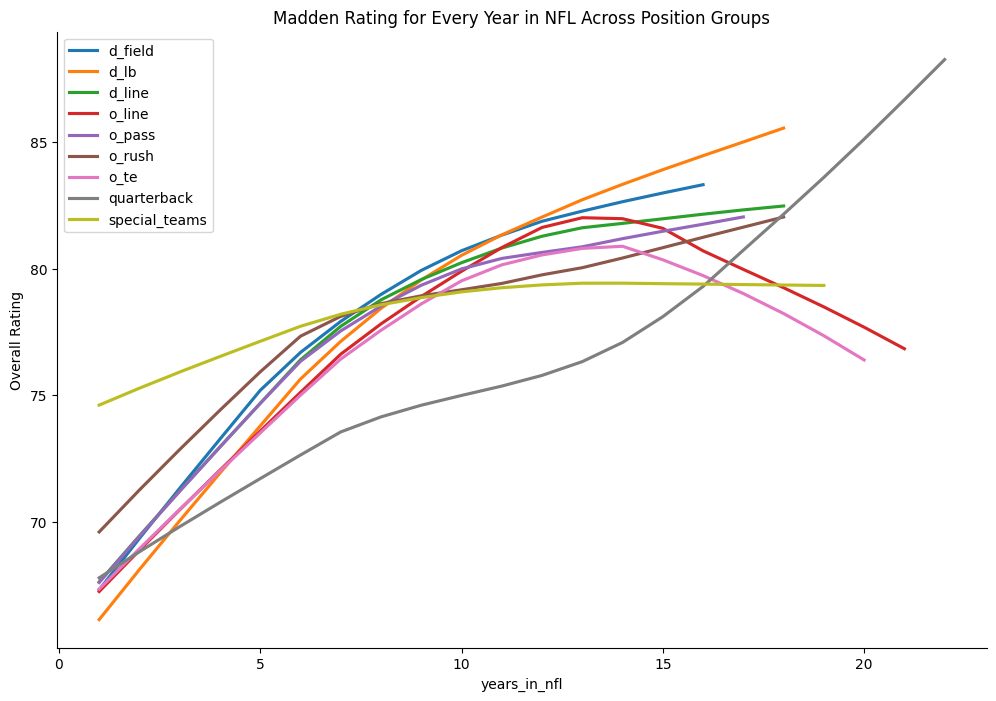

In [24]:
plt.figure(figsize=(12, 8))
sns.set_palette("tab10")
for group in temp["position_group"].unique():
    subset = temp[temp["position_group"] == group]
    sns.regplot(data=subset, x="years_in_nfl", y="overallrating",
                lowess=True, scatter=False, label=group)

plt.legend()
plt.xlabel("years_in_nfl")
plt.ylabel("Overall Rating")
plt.title("Madden Rating for Every Year in NFL Across Position Groups")
sns.despine()
plt.show()

In [25]:
temp = madden_long.groupby(["position_group", "years_in_nfl"])['overall_vs_baseline'].mean().reset_index()
temp

,position_group,years_in_nfl,overall_vs_baseline
0,d_field,1.0,0.000000
1,d_field,2.0,2.041320
2,d_field,3.0,4.860834
3,d_field,4.0,6.324170
4,d_field,5.0,7.516668
...,...,...,...
163,special_teams,15.0,8.097400
164,special_teams,16.0,6.613175
165,special_teams,17.0,6.407188
166,special_teams,18.0,6.414071


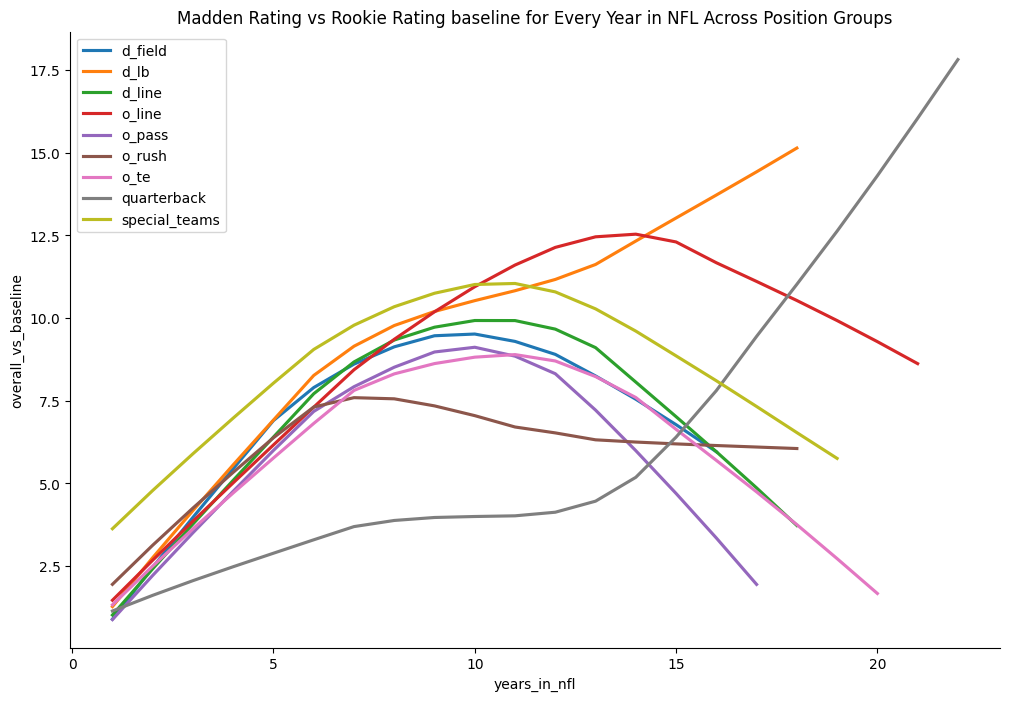

In [26]:
plt.figure(figsize=(12, 8))
sns.set_palette("tab10")
for group in temp["position_group"].unique():
    subset = temp[temp["position_group"] == group]
    sns.regplot(data=subset, x="years_in_nfl", y="overall_vs_baseline",
                lowess=True, scatter=False, label=group)

plt.legend()
plt.xlabel("years_in_nfl")
plt.ylabel("overall_vs_baseline")
plt.title("Madden Rating vs Rookie Rating baseline for Every Year in NFL Across Position Groups")
sns.despine()
plt.show()

In [27]:
madden_long["final_year"] = madden_long.groupby("player_id")["year"].transform("max")
madden_long

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year,rookie_year,years_in_nfl,baseline_overall,overall_vs_baseline,final_year
0,00-0004543,SHANEDRONETT_d_line,DronSh20,Shane Dronett,def,d_line,DL,2001,ATL,1.0,75.000000,53.000000,65.000000,58.000000,79.0000,84.000000,84.000000,79.000000,81.000000,43.000000,7.347195,4,11,35.306958,66.518996,11.000000,20.000000,20.0000,20.00000,16.696763,19.318944,28.000000,-2.261149,-1.546120,2.340851,3.478826,22.000000,6.519022,10.549796,11.996476,9.005981,8.412261,8.034401,16.000000,16.000000,0.483380,15.249485,17.082539,81.000000,51.752871,8.673651,66.456748,21.000000,24.000000,0.675884,2001,2001.0,1.0,75.000000,0.000000,2001.0
1,00-0012842,JASONPETER_d_line,PeteJa20,Jason Peter,def,d_line,DL,2001,CAR,1.0,74.000000,66.000000,74.000000,64.000000,84.0000,78.000000,84.000000,80.000000,67.000000,51.000000,7.889415,5,7,47.836493,58.864012,10.000000,21.000000,21.0000,21.00000,18.295792,21.480056,24.000000,0.980120,-0.375920,8.238861,7.495244,21.000000,5.982346,9.869347,12.073328,5.724684,4.637821,9.797546,27.000000,18.000000,9.782409,19.028072,23.221269,72.000000,54.472249,12.652961,69.286862,18.000000,19.000000,3.772098,2001,2001.0,1.0,74.000000,0.000000,2001.0
2,00-0009978,LEONARDLITTLE_d_line,LittLe00,Leonard Little,def,d_line,DL,2001,LAR,1.0,73.000000,72.000000,62.000000,75.000000,65.0000,70.000000,70.000000,82.000000,64.000000,52.000000,25.090824,8,9,51.656422,55.302556,32.000000,14.000000,14.0000,14.00000,11.934877,13.800475,24.000000,19.994085,18.021897,24.959818,21.045019,40.000000,8.751804,11.499611,12.645619,17.544412,14.431167,17.109987,16.000000,24.000000,-5.096101,32.979157,37.209780,74.000000,51.286358,28.416331,72.007990,11.000000,33.000000,1.131921,2001,2001.0,1.0,73.000000,0.000000,2009.0
3,00-0002142,JUNIORBRYANT_d_line,BryaJu20,Junior Bryant,def,d_line,DL,2001,SF,1.0,72.000000,49.000000,62.000000,55.000000,81.0000,81.000000,84.000000,84.000000,79.000000,43.000000,5.111116,5,9,36.576845,65.727568,24.000000,11.000000,11.0000,11.00000,9.494538,11.093699,14.000000,-8.819708,-2.912042,-5.407254,-5.493794,14.000000,7.008726,10.117281,12.240143,-1.108932,-1.319240,1.354661,29.000000,27.000000,7.181824,14.503342,17.728221,82.000000,51.302609,6.509206,64.948565,12.000000,14.000000,1.162361,2001,2001.0,1.0,72.000000,0.000000,2001.0
4,00-0018054,REINARDWILSON_d_line,WilsRe20,Reinard Wilson,def,d_line,DL,2001,CIN,1.0,69.000000,70.000000,70.000000,65.000000,78.0000,69.000000,78.000000,77.000000,65.000000,50.000000,16.121217,7,9,50.852213,56.274011,31.000000,16.000000,16.0000,16.00000,16.041897,17.385281,26.000000,12.748664,9.218156,18.243457,14.183115,26.000000,7.190139,10.575620,11.980324,12.149089,9.289694,10.978948,13.000000,9.000000,-2.869764,26.808503,31.008670,69.000000,51.400124,22.833778,69.883798,17.000000,21.000000,2.545349,2001,2001.0,1.0,69.000000,0.000000,2003.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62325,00-0039172,JAKEBATES_19990303,BateJa00,Jake Bates,st,special_teams,K,2025,DET,4.0,76.000000,61.000000,74.000000,72.000000,82.0000,35.000000,61.000000,89.000000,59.000000,60.000000,10.000000,3,4,51.000000,15.000000,32.000000,28.000000,22.0000,13.00000,20.000000,20.000000,32.000000,20.000000,10.000000,10.0

In [28]:
madden_long["years_played"] = madden_long["final_year"] - madden_long["rookie_year"] + 1
madden_long["percentage_through_career"] = madden_long["years_in_nfl"] / madden_long["years_played"]

temp = madden_long.groupby(["position_group", "percentage_through_career"])['overallrating'].mean().reset_index()
temp

,position_group,percentage_through_career,overallrating
0,d_field,0.062500,71.650021
1,d_field,0.066667,79.522624
2,d_field,0.071429,73.411818
3,d_field,0.076923,72.714256
4,d_field,0.083333,70.732388
...,...,...,...
906,special_teams,0.937500,77.137962
907,special_teams,0.941176,79.611897
908,special_teams,0.944444,82.500000
909,special_teams,0.947368,77.500000


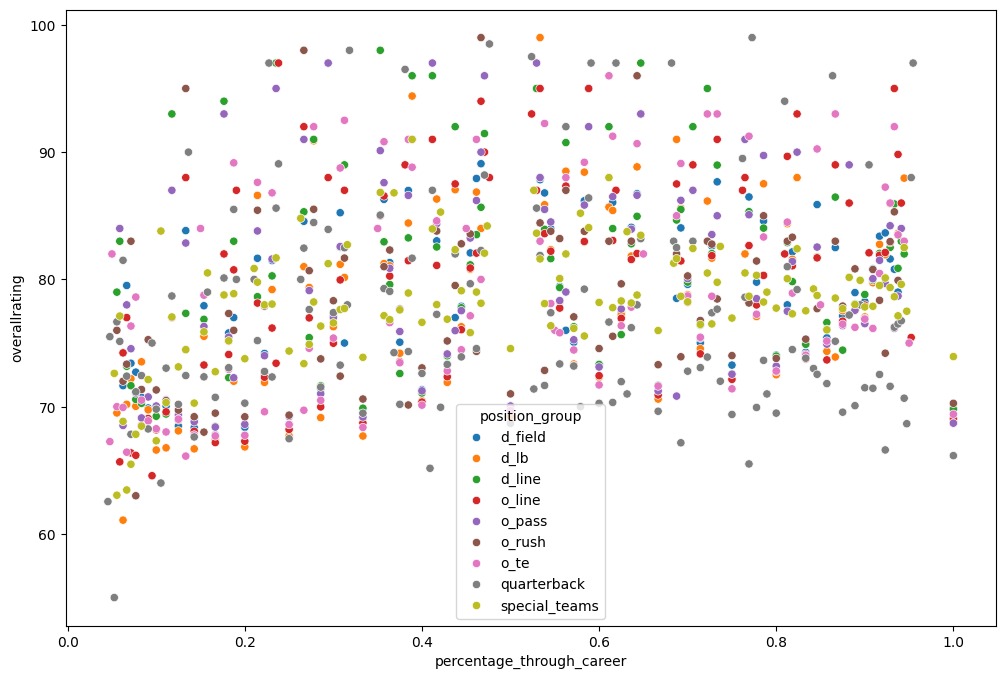

In [29]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=temp, x = "percentage_through_career", y = "overallrating", hue = "position_group")
plt.show()

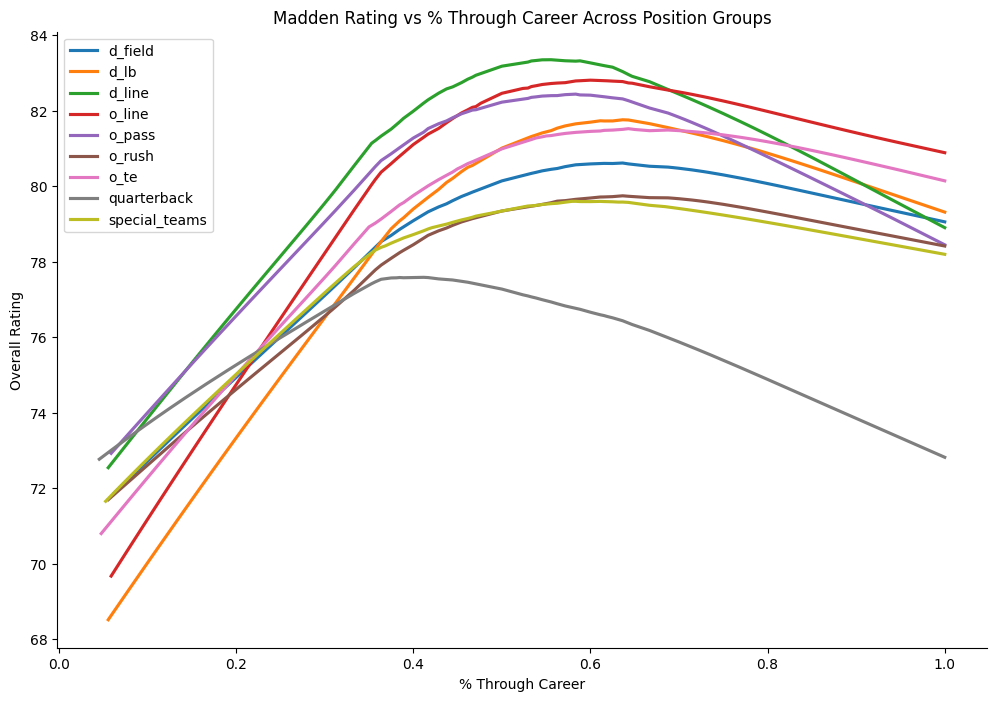

In [30]:
sns.set_palette("tab10")
plt.figure(figsize=(12, 8))

for group in temp["position_group"].unique():
    subset = temp[temp["position_group"] == group]
    sns.regplot(data=subset, x="percentage_through_career", y="overallrating",
                lowess=True, scatter=False, label=group)

plt.legend()
plt.xlabel("% Through Career")
plt.ylabel("Overall Rating")
plt.title("Madden Rating vs % Through Career Across Position Groups")
sns.despine()
plt.show()

What if I normalized rating or did rating above baseline? That might be super interesting and would explain why the QB graph is so much lower than the others

In [31]:
madden_long["years_played"] = madden_long["final_year"] - madden_long["rookie_year"] + 1
madden_long["percentage_through_career"] = madden_long["years_in_nfl"] / madden_long["years_played"]

temp = madden_long.groupby(["position_group", "percentage_through_career"])['overall_vs_baseline'].mean().reset_index()
temp

,position_group,percentage_through_career,overall_vs_baseline
0,d_field,0.062500,0.000000
1,d_field,0.066667,0.000000
2,d_field,0.071429,0.000000
3,d_field,0.076923,0.000000
4,d_field,0.083333,0.000000
...,...,...,...
906,special_teams,0.937500,6.166500
907,special_teams,0.941176,4.468582
908,special_teams,0.944444,19.456365
909,special_teams,0.947368,1.204878


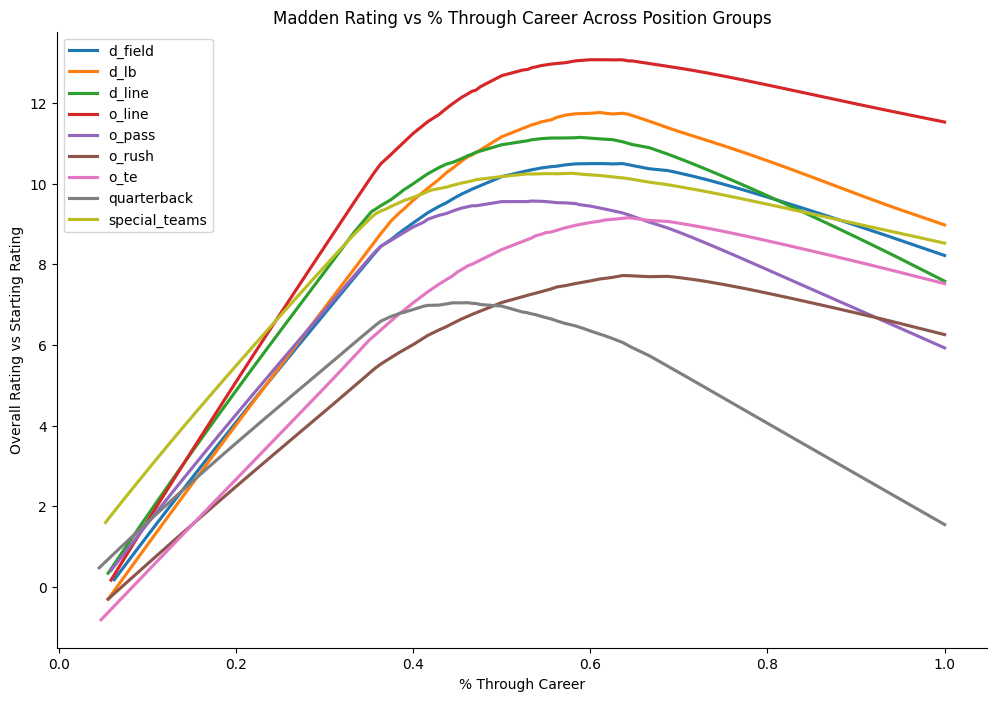

In [32]:
sns.set_palette("tab10")
plt.figure(figsize=(12, 8))

for group in temp["position_group"].unique():
    subset = temp[temp["position_group"] == group]
    sns.regplot(data=subset, x="percentage_through_career", y="overall_vs_baseline",
                lowess=True, scatter=False, label=group)

plt.legend()
plt.xlabel("% Through Career")
plt.ylabel("Overall Rating vs Starting Rating")
plt.title("Madden Rating vs % Through Career Across Position Groups")
sns.despine()
plt.show()

### Another One

<Axes: xlabel='years_played', ylabel='speed'>

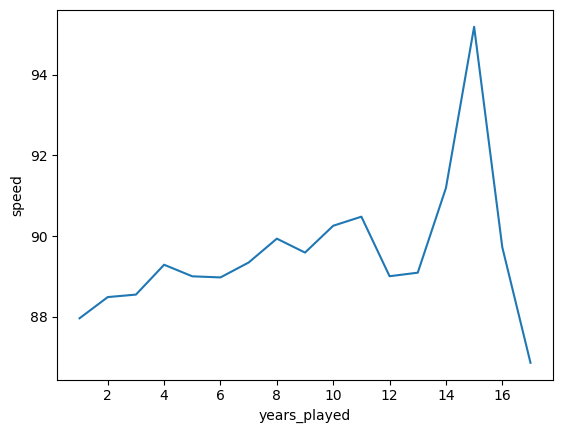

In [37]:
temp = madden_long.query("position == 'WR'")[["speed", "years_played"]].groupby("years_played").mean().reset_index()
sns.lineplot(temp, x = "years_played", y = "speed")


In [45]:
madden_long.query("years_played > 5")

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year,rookie_year,years_in_nfl,baseline_overall,overall_vs_baseline,final_year,years_played,percentage_through_career
2,00-0009978,LEONARDLITTLE_d_line,LittLe00,Leonard Little,def,d_line,DL,2001,LAR,1.0,73.000000,72.000000,62.000000,75.000000,65.0000,70.000000,70.000000,82.000000,64.000000,52.000000,25.090824,8,9,51.656422,55.302556,32.000000,14.000000,14.0000,14.00000,11.934877,13.800475,24.000000,19.994085,18.021897,24.959818,21.045019,40.000000,8.751804,11.499611,12.645619,17.544412,14.431167,17.109987,16.000000,24.000000,-5.096101,32.979157,37.209780,74.000000,51.286358,28.416331,72.007990,11.000000,33.000000,1.131921,2001,2001.0,1.0,73.000000,0.000000,2009.0,9.0,0.111111
6,00-0015468,PAULSPICER_d_line,SpicPa20,Paul Spicer,def,d_line,DL,2001,JAX,0.0,68.000000,53.000000,52.000000,60.000000,67.0000,82.000000,65.000000,79.000000,67.000000,45.000000,7.039051,7,9,34.373868,54.284754,20.000000,13.000000,13.0000,13.00000,13.554221,15.142286,20.000000,1.927224,-1.911711,3.003191,-0.061781,20.000000,5.476030,9.346660,10.911023,3.331995,2.954281,11.211634,15.000000,15.000000,-0.179400,20.881419,22.337868,78.000000,46.035811,13.116954,61.282599,19.000000,9.000000,-0.218800,2001,2001.0,1.0,68.000000,0.000000,2009.0,9.0,0.111111
15,00-0019573,ROBAIRESMITH_19771115,SmitRo21,Robaire Smith,def,d_line,DL,2001,TEN,1.0,62.000000,46.000000,74.000000,59.000000,79.0000,78.000000,77.000000,83.000000,57.000000,45.000000,4.487289,7,6,31.084698,46.339342,23.000000,19.000000,19.0000,19.00000,17.742071,20.454300,19.000000,4.134142,-3.459721,4.178176,3.201712,18.000000,7.006197,10.572747,10.788966,5.210070,7.933604,15.935493,15.000000,20.000000,6.411200,23.253240,24.722587,72.000000,47.200338,18.380913,68.606102,25.000000,15.000000,3.063913,2001,2001.0,1.0,62.000000,0.000000,2010.0,10.0,0.100000
19,00-0013471,MONTAEREAGOR_d_line,ReagMo20,Montae Reagor,def,d_line,DL,2001,DEN,1.0,61.000000,53.000000,63.000000,59.000000,77.0000,78.000000,79.000000,87.000000,58.000000,46.000000,5.169902,6,8,38.233934,48.525453,22.000000,11.000000,11.0000,11.00000,11.674221,12.422867,19.000000,3.166719,-0.941310,2.346241,1.954276,11.000000,5.441423,9.100068,10.621993,1.313246,1.288348,11.145777,12.000000,15.000000,0.571875,22.087081,24.616059,74.000000,50.859583,19.108387,66.426119,25.000000,20.000000,2.250414,2001,2001.0,1.0,61.000000,0.000000,2007.0,7.0,0.142857
22,00-0019630,KENDRICKCLANCY_d_line,ClanKe20,Kendrick Clancy,def,d_line,DL,2001,PIT,1.0,60.000000,53.000000,57.000000,57.000000,78.0000,80.000000,81.000000,87.000000,56.000000,42.000000,10.171708,6,5,37.673528,48.410776,11.000000,18.000000,18.0000,18.00000,18.599091,21.731594,17.000000,0.331308,1.959024,2.586631,5.000271,12.000000,5.662993,9.601606,10.958011,-2.325451,-4.553330,14.422308,31.000000,17.000000,24.817734,20.601566,22.345757,76.000000,53.462641,15.691934,67.256972,11.000000,25.000000,5.602620,2001,2001.0,1.0,60.000000,0.000000,2009.0,9.0,0.111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62320,00-0034794,JASONSANDERS_19951116,SandJa00,Jason Sanders,st,special_teams,K,2025,MIA,5.0,77.000000,58.000000,78.000000,77.000000,81.0000,37.000000,53.000000,83.000000,65.000000,31.000000,

In [51]:
active_contracts = contracts.query("is_active == True")
active_second_contracts = active_contracts.query("year_signed > draft_year + 1")
active_second_contracts.query("draft_year > 2022")

,player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,player_page,otc_id,gsis_id,date_of_birth,height,weight,college,draft_year,draft_round,draft_overall,draft_team,cols
377,Tyson Bagent,QB,Bears,True,2025,2.0,10.000,5.0000,2.53,0.018,10.787966,5.393983,2.729355,https://overthecap.com/player/tyson-bagent/11238/,11238,00-0038416,None,"6'3""",213,Shepherd,2023.0,NaN,NaN,Bears,"[{'year': '2023', 'team': 'Bears', 'base_salar..."
583,Tommy DeVito,QB,Patriots,True,2026,2.0,4.400,2.2000,2.00,0.007,4.400000,2.200000,2.000000,https://overthecap.com/player/tommy-devito/11293/,11293,00-0038476,None,"6'2""",210,Syracuse,2023.0,NaN,NaN,Giants,"[{'year': '2023', 'team': 'Giants', 'base_sala..."
1080,Hendon Hooker,QB,Titans,True,2026,2.0,2.405,1.2025,0.00,0.004,2.405000,1.202500,0.000000,https://overthecap.com/player/hendon-hooker/10...,10892,00-0038550,None,"6'3""",217,Tennessee,2023.0,3.0,68.0,Lions,"[{'year': '2023', 'team': 'Lions', 'base_salar..."
1255,Sean Clifford,QB,Bengals,True,2026,1.0,1.075,1.0750,0.00,0.004,1.075000,1.075000,0.000000,https://overthecap.com/player/sean-clifford/10...,10973,00-0038391,None,"6'2""",212,Penn State,2023.0,5.0,149.0,Packers,"[{'year': '2023', 'team': 'Packers', 'base_sal..."
1353,Carter Bradley,QB,Jaguars,True,2026,1.0,1.005,1.0050,0.00,0.003,1.005000,1.005000,0.000000,https://overthecap.com/player/carter-bradley/1...,11921,00-0039534,None,"6'3""",216,South Alabama,2024.0,NaN,NaN,Raiders,"[{'year': '2024', 'team': 'Raiders', 'base_sal..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50087,Harrison Mevis,K,Rams,True,2026,1.0,1.005,1.0050,0.00,0.003,1.005000,1.005000,0.000000,https://overthecap.com/player/harrison-mevis/1...,12253,00-0039498,None,"5'11""",243,Missouri,2024.0,NaN,NaN,Panthers,"[{'year': '2025', 'team': 'Rams', 'base_salary..."
50919,Nik Constantinou,P,Browns,True,2026,1.0,0.885,0.8850,0.00,0.003,0.885000,0.885000,0.000000,https://overthecap.com/player/nik-constantinou...,12141,None,None,"6'3""",225,Texas A&M,2024.0,NaN,NaN,Broncos,None
51276,Chris Stoll,LS,Seahawks,True,2026,2.0,2.905,1.4525,1.20,0.005,2.905000,1.452500,1.200000,https://overthecap.com/player/chris-stoll/11497/,11497,00-0038769,None,"6'2""",255,Penn State,2023.0,NaN,NaN,Seahawks,"[{'year': '2023', 'team': 'Seahawks', 'base_sa..."
51368,Alex Ward,LS,Raiders,True,2026,1.0,1.145,1.1450,0.00,0.004,1.145000,1.145000,0.000000,https://overthecap.com/player/alex-ward/11110/,11110,00-0038360,None,"6'4""",240,Central Florida,2023.0,NaN,NaN,Rams,"[{'year': '2023', 'team': 'Rams', 'base_salary..."


In [ ]:
#next I can see which players are still active and make that as a boolean column in the df and then I can left join with the contract info and then I'll have madden ratings and contracts. Join by gsis_id